# Введение. Полносвязные слои. Функции активации (ноутбук)

> Начнем осваивать библиотеку `PyTorch`.

## План ноутбука

1. Установка `PyTorch`
1. Введение в `PyTorch`
1. Полносвязные слои и функции активации в `PyTorch`
1. Градиентный спуск своими руками

## Установка `PyTorch`

Мы будем использовать библиотеку для глубинного обучения `PyTorch`, ее можно не устанавливать, можно пользоваться сайтами [Kaggle](kaggle.com) и [Google Colab](colab.research.google.com/).

Чтобы установить `PyTorch` локально себе на компьютер нужно ответить на два вопроса - какая у вас операционная система и есть ли у вас дискретная видеокарта (GPU) и если есть, то какого производителя. В зависимости от ваших ответов мы получаем три варианта по операционной системе - Linux, Mac и Windows; три варианта по дискретной видеокарте - нет видеокарты (доступен только центральный процессор CPU), есть видеокарта от Nvidia или есть видеокарта от AMD (это производитель именно чипа, конечный вендор может быть другой, например, ASUS, MSI, Palit). Работа с PyTorch с видеокартой от AMD это экзотика, которая выходит за рамки нашего курса, поэтому рассмотрим только варианты *нет видеокарты*/*есть видеокарта от Nvidia*.


Выберите на [сайте](https://pytorch.org/get-started/locally/) подходящие вам варианты операционной системы/видеокарты и скопируйте команду для установки. Разберем подробно самые популярные варианты установки:

### Установка в Linux ([поддерживаемые дистрибутивы](https://pytorch.org/get-started/locally/#supported-linux-distributions))

На линуксе будет работать поддержка `PyTorch` в любой конфигурации, что у вас нет видеокарты, что есть от Nvidia, что от AMD.

Пререквизит для работы с видеокартой от Nvidia - нужно поставить CUDA, это инструмент от компании Nvidia, который позволяет ускорять вычисления на их же ГПУ. Чтобы поставить себе на машину все правильно воспользуйтесь этим [гайдом](https://docs.nvidia.com/cuda/cuda-installation-guide-linux/index.html) от Nvidia.

`pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu` для тех, у кого нет видеокарты.

`pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116` для тех, у кого есть видеокарта (либо другой `--extra-index-url`, смотрите на сайте PyTorch, в зависимости от версии CUDA).

### Установка на Mac

На маках есть пока что поддержка `PyTorch` только центрального процессора, чуть позже появится поддержка ускорения на чипах M1, M2, M1 Pro и так далее.

 - **pip**

`pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu`

 - **conda**

`conda install pytorch torchvision torchaudio cpuonly -c pytorch`

In [2]:
!nvidia-smi

Tue Sep  8 13:07:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:82:00.0 Off |                    0 |
| N/A   33C    P0             78W /  500W |    3729MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Введение в `PyTorch`

### Тензоры

Тензоры — это специализированная структура данных, по сути это массивы и матрицы. Тензоры очень похожи на массивы в numpy, так что, если у вас хорошо с numpy, то разобраться в PyTorch тензорах будет очень просто. В PyTorch мы используем тензоры для кодирования входных и выходных данных модели, а также параметров модели.

In [3]:
import torch
import numpy as np

### Создание тензоров

Тензор можно создать напрямую из каких-то данных - нам подходят все списки с числами:

In [4]:
some_data = [1, 2, 3, 4]
some_tensor = torch.tensor(some_data)

some_tensor

tensor([1, 2, 3, 4])

In [5]:
some_data = [[1, 2], [3, 4], [5, 6]]
some_tensor = torch.tensor(some_data)

some_tensor

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [6]:
some_data = [[[1], [2]], [[3], [4]], [[5], [6]]]
some_tensor = torch.tensor(some_data)

some_tensor

tensor([[[1],
         [2]],

        [[3],
         [4]],

        [[5],
         [6]]])

На самом деле про "все" списки с числами - обман. Если у вашего списка есть какой-то уровень вложенности, то должны совпадать размерности у всех вложенных списков (подробнее про размерности поговорим позже):

In [7]:
some_other_data = [[1, 2], [3, 4], [5, 6, 7]]
some_other_tensor = torch.tensor(some_other_data)

some_other_tensor

ValueError: expected sequence of length 2 at dim 1 (got 3)

Также тензоры можно создавать из numpy массивов и наоборот:

In [8]:
some_numpy_array = np.array(some_data)

some_numpy_array

array([[[1],
        [2]],

       [[3],
        [4]],

       [[5],
        [6]]])

In [9]:
torch.tensor(some_numpy_array)

tensor([[[1],
         [2]],

        [[3],
         [4]],

        [[5],
         [6]]])

In [10]:
some_tensor_from_numpy = torch.from_numpy(some_numpy_array)

some_tensor_from_numpy

tensor([[[1],
         [2]],

        [[3],
         [4]],

        [[5],
         [6]]])

При этом если мы создаем тензор из numpy массива с помощью `torch.from_numpy`, то они делят между собой память, где лежат их данные и, соответственно, при изменении тензора меняется numpy массив и наоборот:

In [11]:
x = np.ones(10)
y = torch.from_numpy(x)

x += 1

x, y

(array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.]),
 tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.], dtype=torch.float64))

In [12]:
x = torch.ones(10)
y = x.numpy()

x += 1

x, y

(tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.]),
 array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2.], dtype=float32))

Можем создать тензор со случайными или константными значениями:

In [13]:
shape = (2, 3)

random_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)
empty_tensor = torch.empty(shape)

random_tensor, ones_tensor, zeros_tensor, empty_tensor

(tensor([[0.7559, 0.3292, 0.5354],
         [0.1627, 0.0223, 0.7749]]),
 tensor([[1., 1., 1.],
         [1., 1., 1.]]),
 tensor([[0., 0., 0.],
         [0., 0., 0.]]),
 tensor([[-6.6620e+13,  4.5588e-41, -5.4453e+14],
         [ 4.5588e-41, -6.6866e+13,  4.5588e-41]]))

In [14]:
torch.diag(torch.tensor([1, 2, 3]))

tensor([[1, 0, 0],
        [0, 2, 0],
        [0, 0, 3]])

Теперь поговорим про размерности подробнее.

У тензора есть какой-то размер, какая форма. Первое с чем нужно определиться, какой **размерности** тензор.

In [15]:
shape = (10)  # одна размерность (вектор)

tensor = torch.rand(shape)

tensor

tensor([0.7800, 0.1451, 0.7027, 0.8745, 0.6795, 0.7518, 0.9117, 0.6506, 0.1770,
        0.3746])

In [16]:
shape = (2, 3)  # две размерности (матрица)

tensor = torch.rand(shape)

tensor

tensor([[0.4842, 0.3151, 0.7541],
        [0.9792, 0.4661, 0.8361]])

In [17]:
shape = (3, 2, 3)  # три размерности (и больше - тензор)

tensor = torch.rand(shape)

tensor

tensor([[[0.4167, 0.2746, 0.7509],
         [0.2192, 0.3306, 0.7373]],

        [[0.4926, 0.9005, 0.3244],
         [0.7946, 0.3047, 0.0275]],

        [[0.0475, 0.1576, 0.2306],
         [0.0178, 0.9983, 0.3383]]])

Тензор с размерностью 1 - это просто вектор, список чисел.

Тензор с размерностью 2 - это просто матрица, то есть список списков чисел.

Тензор с размерностью 3 и больше - это тензор, то есть список списков списков ... чисел.

Получить доступ к размеру уже созданного тензора - метод `.shape`:

In [18]:
some_data = [[[1], [2]], [[3], [4]], [[5], [6]]]
some_tensor = torch.tensor(some_data)

print(some_tensor)
print(some_tensor.shape)

tensor([[[1],
         [2]],

        [[3],
         [4]],

        [[5],
         [6]]])
torch.Size([3, 2, 1])


In [19]:
torch.ones((3, 2, 1)).shape

torch.Size([3, 2, 1])

На первом семинаре по мо мы говорили про изображения, давайте сделаем тензор, который будет нам имитировать изображение - сделаем его размер `(c, h, w)`, где `h` и `w` это его высота и ширина, а `c` - число каналов в цветовом пространстве (в черно-белом 1, в RGB 3):

In [ ]:
h = 9
w = 16
c = 3

shape = (c, h, w)

image_tensor = torch.rand(shape)

image_tensor

tensor([[[0.1534, 0.2995, 0.7777, 0.5949, 0.6173, 0.2960, 0.4036, 0.4981,
          0.8146, 0.8583, 0.1851, 0.0842, 0.1553, 0.1820, 0.5061, 0.9884],
         [0.3714, 0.7573, 0.8038, 0.7147, 0.7984, 0.2166, 0.2345, 0.6307,
          0.8998, 0.0560, 0.5416, 0.3539, 0.5245, 0.0779, 0.1312, 0.9494],
         [0.0534, 0.8692, 0.6658, 0.5601, 0.6970, 0.6221, 0.3755, 0.9299,
          0.2662, 0.9339, 0.8290, 0.6536, 0.2726, 0.3986, 0.3222, 0.2087],
         [0.6823, 0.3582, 0.2469, 0.1980, 0.7491, 0.6000, 0.1149, 0.0109,
          0.8031, 0.8973, 0.5061, 0.8955, 0.8176, 0.1777, 0.7194, 0.1798],
         [0.9491, 0.8052, 0.9137, 0.6357, 0.2319, 0.9217, 0.7085, 0.9243,
          0.1289, 0.0669, 0.6115, 0.2764, 0.7472, 0.6787, 0.3226, 0.8753],
         [0.0810, 0.5632, 0.5011, 0.6894, 0.1937, 0.3367, 0.5615, 0.6897,
          0.8973, 0.3635, 0.6230, 0.1565, 0.5085, 0.3081, 0.5325, 0.4457],
         [0.3613, 0.4068, 0.6611, 0.7919, 0.3290, 0.1037, 0.0237, 0.5299,
          0.3334, 0.7731, 0.1930

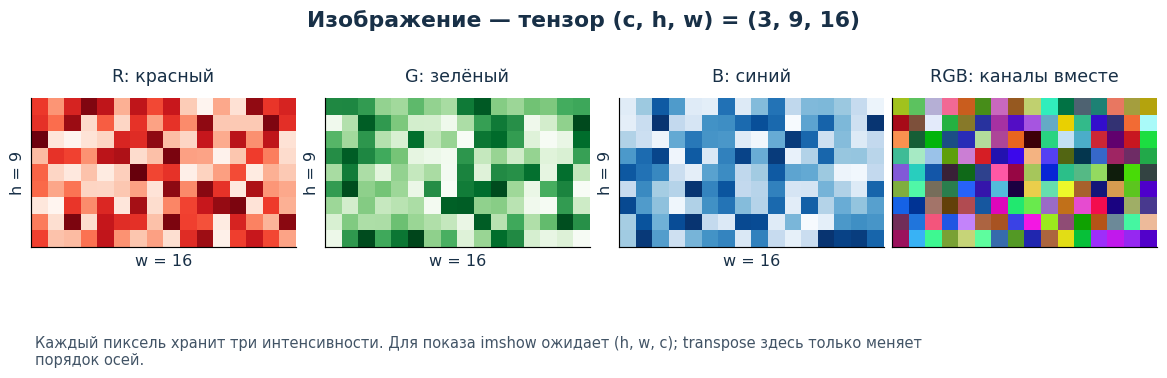

In [21]:
image_tensor.shape

torch.Size([3, 9, 16])

Можем попробовать поменять размер тензора, например, [вытянуть его в вектор](https://pytorch.org/docs/stable/generated/torch.ravel.html):

In [22]:
image_tensor.ravel()

tensor([0.1534, 0.2995, 0.7777, 0.5949, 0.6173, 0.2960, 0.4036, 0.4981, 0.8146,
        0.8583, 0.1851, 0.0842, 0.1553, 0.1820, 0.5061, 0.9884, 0.3714, 0.7573,
        0.8038, 0.7147, 0.7984, 0.2166, 0.2345, 0.6307, 0.8998, 0.0560, 0.5416,
        0.3539, 0.5245, 0.0779, 0.1312, 0.9494, 0.0534, 0.8692, 0.6658, 0.5601,
        0.6970, 0.6221, 0.3755, 0.9299, 0.2662, 0.9339, 0.8290, 0.6536, 0.2726,
        0.3986, 0.3222, 0.2087, 0.6823, 0.3582, 0.2469, 0.1980, 0.7491, 0.6000,
        0.1149, 0.0109, 0.8031, 0.8973, 0.5061, 0.8955, 0.8176, 0.1777, 0.7194,
        0.1798, 0.9491, 0.8052, 0.9137, 0.6357, 0.2319, 0.9217, 0.7085, 0.9243,
        0.1289, 0.0669, 0.6115, 0.2764, 0.7472, 0.6787, 0.3226, 0.8753, 0.0810,
        0.5632, 0.5011, 0.6894, 0.1937, 0.3367, 0.5615, 0.6897, 0.8973, 0.3635,
        0.6230, 0.1565, 0.5085, 0.3081, 0.5325, 0.4457, 0.3613, 0.4068, 0.6611,
        0.7919, 0.3290, 0.1037, 0.0237, 0.5299, 0.3334, 0.7731, 0.1930, 0.4523,
        0.2045, 0.2995, 0.5768, 0.7707, 

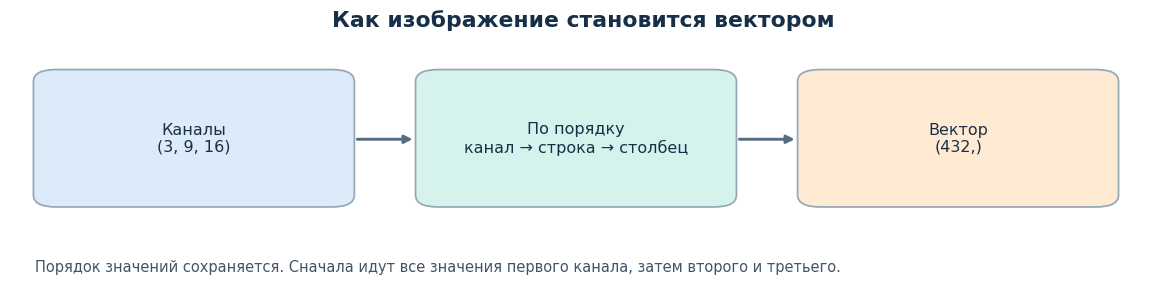

In [23]:
image_tensor.ravel().shape

torch.Size([432])

У ravel вектор хранится contiguous, элементы идут подряд в памяти. При необходимости копирует данные.

In [24]:
h * w * c

432

In [25]:
image_tensor.flatten()

tensor([0.1534, 0.2995, 0.7777, 0.5949, 0.6173, 0.2960, 0.4036, 0.4981, 0.8146,
        0.8583, 0.1851, 0.0842, 0.1553, 0.1820, 0.5061, 0.9884, 0.3714, 0.7573,
        0.8038, 0.7147, 0.7984, 0.2166, 0.2345, 0.6307, 0.8998, 0.0560, 0.5416,
        0.3539, 0.5245, 0.0779, 0.1312, 0.9494, 0.0534, 0.8692, 0.6658, 0.5601,
        0.6970, 0.6221, 0.3755, 0.9299, 0.2662, 0.9339, 0.8290, 0.6536, 0.2726,
        0.3986, 0.3222, 0.2087, 0.6823, 0.3582, 0.2469, 0.1980, 0.7491, 0.6000,
        0.1149, 0.0109, 0.8031, 0.8973, 0.5061, 0.8955, 0.8176, 0.1777, 0.7194,
        0.1798, 0.9491, 0.8052, 0.9137, 0.6357, 0.2319, 0.9217, 0.7085, 0.9243,
        0.1289, 0.0669, 0.6115, 0.2764, 0.7472, 0.6787, 0.3226, 0.8753, 0.0810,
        0.5632, 0.5011, 0.6894, 0.1937, 0.3367, 0.5615, 0.6897, 0.8973, 0.3635,
        0.6230, 0.1565, 0.5085, 0.3081, 0.5325, 0.4457, 0.3613, 0.4068, 0.6611,
        0.7919, 0.3290, 0.1037, 0.0237, 0.5299, 0.3334, 0.7731, 0.1930, 0.4523,
        0.2045, 0.2995, 0.5768, 0.7707, 

In [26]:
image_tensor.flatten().shape

torch.Size([432])

Flatten cохраняет общую память с исходным тензором, если возможно, и не гарантирует contiguous.

Посчитаем количество элементов в тензоре с помощью [специальной функции](https://pytorch.org/docs/stable/generated/torch.numel.html):

In [27]:
image_tensor.shape

torch.Size([3, 9, 16])

In [28]:
image_tensor.numel()

432

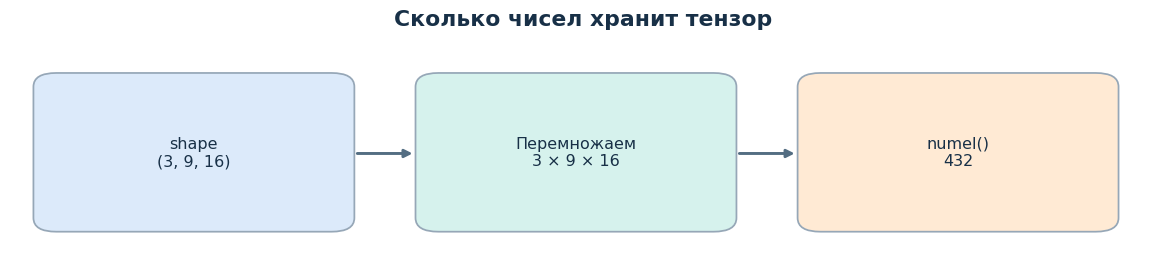

In [29]:
h = 2
w = 3
c = 3

shape = (c, h, w)

image_tensor = torch.rand(shape)

image_tensor

tensor([[[0.6941, 0.6804, 0.5918],
         [0.8078, 0.6131, 0.6284]],

        [[0.0696, 0.7596, 0.0980],
         [0.7002, 0.7377, 0.0357]],

        [[0.9124, 0.3812, 0.4450],
         [0.9205, 0.0330, 0.0743]]])

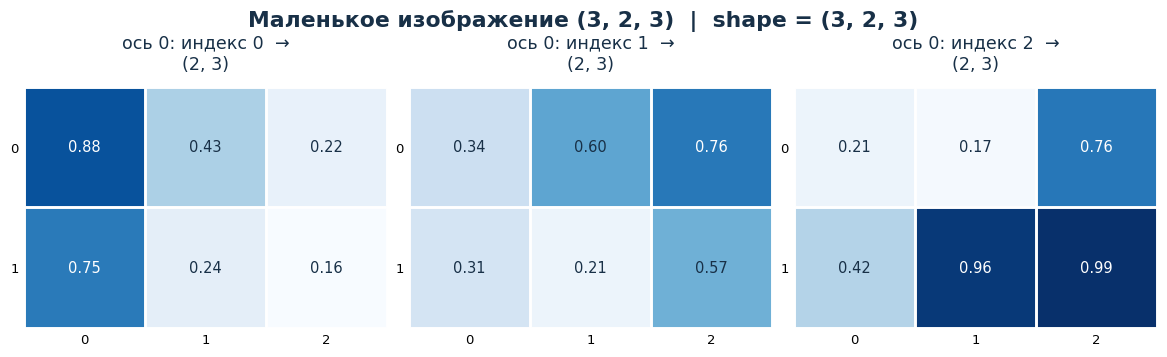

Попробуем поменять размер с помощью функции [reshape](https://pytorch.org/docs/stable/generated/torch.reshape.html#torch.reshape):

In [33]:
image_tensor.reshape(c, h * w)

tensor([[0.8777, 0.4331, 0.2249, 0.7498, 0.2409, 0.1626],
        [0.3403, 0.6049, 0.7574, 0.3058, 0.2057, 0.5674],
        [0.2053, 0.1745, 0.7606, 0.4160, 0.9569, 0.9864]])

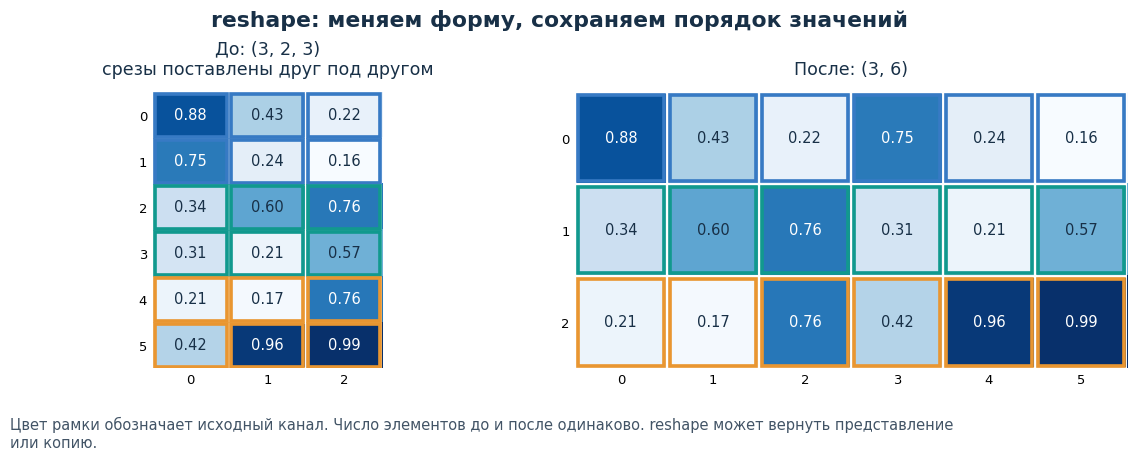

In [30]:
image_tensor.reshape(c, h * w).shape

torch.Size([3, 6])

Попробуем собрать из нескольких тензоров один большой:

[torch.cat](https://pytorch.org/docs/stable/generated/torch.cat.html#torch.cat)

In [31]:
x = torch.randn(2, 3)

x

tensor([[ 0.6054,  1.7318, -2.2287],
        [-0.7080, -0.8844,  0.2730]])

In [32]:
torch.cat((x, x, x), dim=0)

tensor([[ 0.6054,  1.7318, -2.2287],
        [-0.7080, -0.8844,  0.2730],
        [ 0.6054,  1.7318, -2.2287],
        [-0.7080, -0.8844,  0.2730],
        [ 0.6054,  1.7318, -2.2287],
        [-0.7080, -0.8844,  0.2730]])

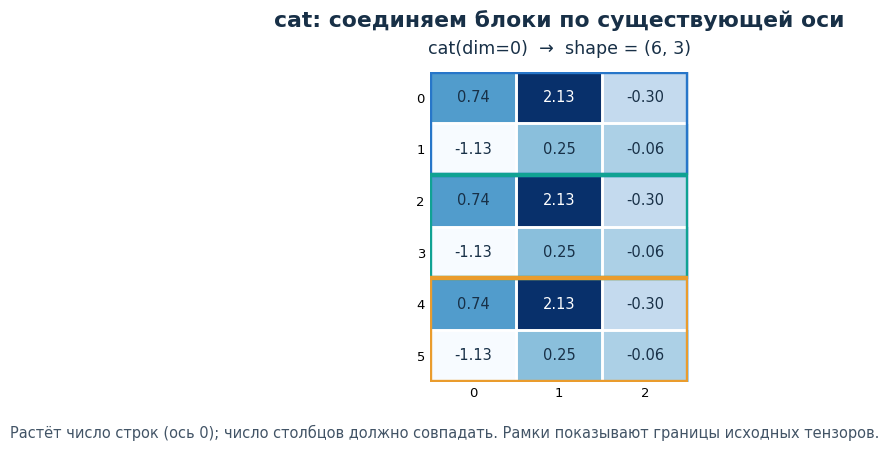

In [33]:
torch.cat((x, x, x), dim=1)

tensor([[ 0.6054,  1.7318, -2.2287,  0.6054,  1.7318, -2.2287,  0.6054,  1.7318,
         -2.2287],
        [-0.7080, -0.8844,  0.2730, -0.7080, -0.8844,  0.2730, -0.7080, -0.8844,
          0.2730]])

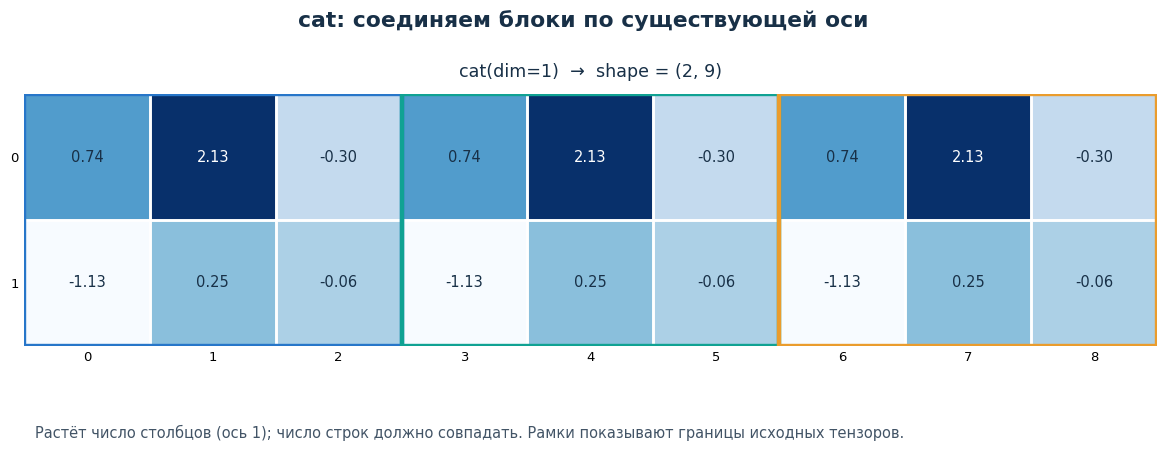

In [34]:
x = torch.randn(3, 3)
y = torch.randn(5, 3)
z = torch.randn(1, 3)

for tensor in [x, y, z]:
    print(tensor)

torch.cat((x, y, z), dim=0)

tensor([[-2.4672,  1.4003,  0.8133],
        [ 0.1287,  0.0970,  0.8305],
        [ 0.4492, -1.0147,  0.1175]])
tensor([[ 0.4951,  0.4497, -1.9602],
        [ 0.7500,  0.1442, -1.2329],
        [-0.9173,  2.0006, -0.9539],
        [ 0.2006, -1.6566, -0.6292],
        [-0.1440, -1.4087,  0.1686]])
tensor([[-0.4923, -0.6676,  0.6012]])


tensor([[-2.4672,  1.4003,  0.8133],
        [ 0.1287,  0.0970,  0.8305],
        [ 0.4492, -1.0147,  0.1175],
        [ 0.4951,  0.4497, -1.9602],
        [ 0.7500,  0.1442, -1.2329],
        [-0.9173,  2.0006, -0.9539],
        [ 0.2006, -1.6566, -0.6292],
        [-0.1440, -1.4087,  0.1686],
        [-0.4923, -0.6676,  0.6012]])

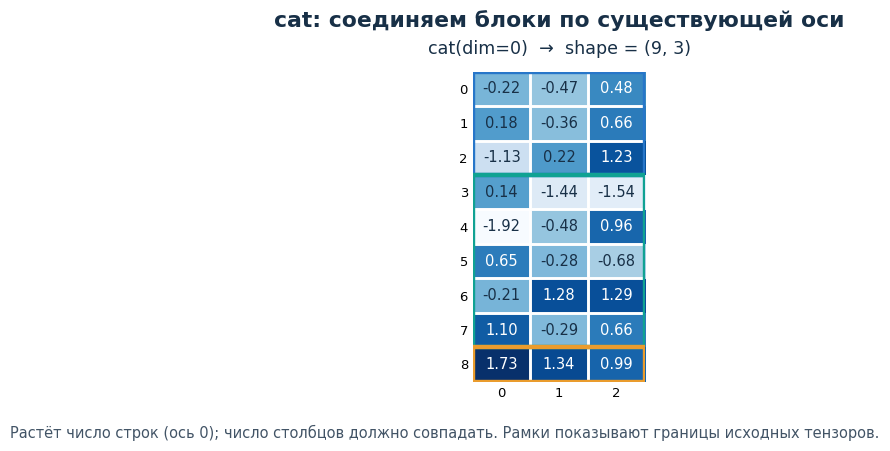

In [35]:
torch.cat((x, y, z), dim=1)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 3 but got size 5 for tensor number 1 in the list.

In [36]:
x = torch.randn(2, 3)
y = torch.randn(2, 5)
z = torch.randn(2, 1)

for tensor in [x, y, z]:
    print(tensor)

torch.cat((x, y, z), dim=1)

tensor([[-0.2768,  1.1397, -1.3420],
        [ 1.1671,  0.6034, -0.3675]])
tensor([[-0.6676,  0.0959,  1.5752,  0.5101, -1.6465],
        [-0.4277,  0.9216,  0.6246,  0.2523, -1.0865]])
tensor([[1.4436],
        [0.2266]])


tensor([[-0.2768,  1.1397, -1.3420, -0.6676,  0.0959,  1.5752,  0.5101, -1.6465,
          1.4436],
        [ 1.1671,  0.6034, -0.3675, -0.4277,  0.9216,  0.6246,  0.2523, -1.0865,
          0.2266]])

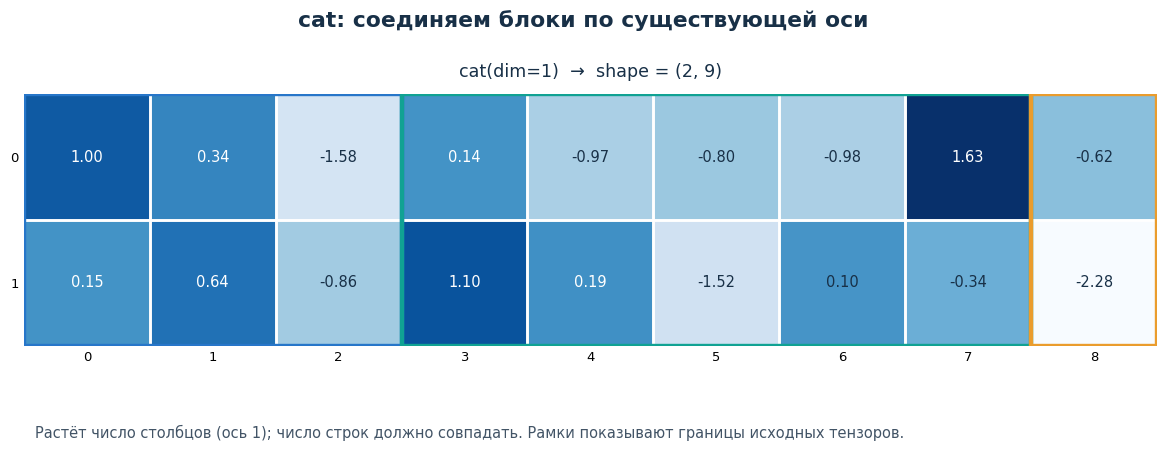

In [37]:
torch.cat((x, y, z), dim=0)

RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 3 but got size 5 for tensor number 1 in the list.

Теперь добавим дополнительную ось:

[torch.unsqueeze](https://pytorch.org/docs/stable/generated/torch.unsqueeze.html)

In [38]:
x = torch.rand(2, 3)

print(x)
print()
print(x.unsqueeze(0), x.unsqueeze(0).shape)
print()
print(x.unsqueeze(1), x.unsqueeze(1).shape)
print()
print(x.unsqueeze(2), x.unsqueeze(2).shape)
print()
print(x.unsqueeze(2), x.unsqueeze(-1).shape)

tensor([[0.3197, 0.0320, 0.1010],
        [0.8542, 0.0959, 0.6398]])

tensor([[[0.3197, 0.0320, 0.1010],
         [0.8542, 0.0959, 0.6398]]]) torch.Size([1, 2, 3])

tensor([[[0.3197, 0.0320, 0.1010]],

        [[0.8542, 0.0959, 0.6398]]]) torch.Size([2, 1, 3])

tensor([[[0.3197],
         [0.0320],
         [0.1010]],

        [[0.8542],
         [0.0959],
         [0.6398]]]) torch.Size([2, 3, 1])

tensor([[[0.3197],
         [0.0320],
         [0.1010]],

        [[0.8542],
         [0.0959],
         [0.6398]]]) torch.Size([2, 3, 1])


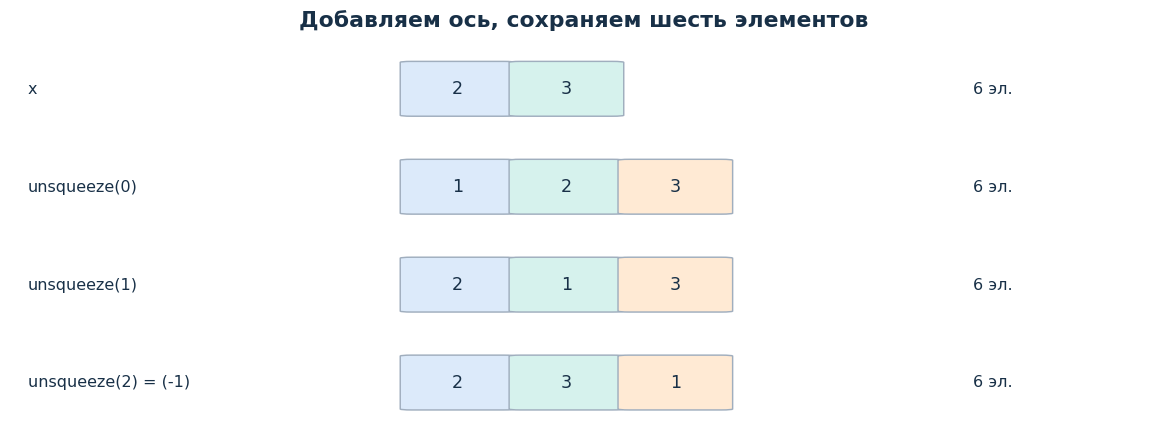

Уберем лишние оси (где размер единичка):

In [39]:
x = torch.rand(1, 2, 1, 3)

print(x)
print()
print(x.squeeze(), x.squeeze().shape)
print()
print(x.squeeze(0), x.squeeze(0).shape)

tensor([[[[0.9072, 0.4598, 0.6779]],

         [[0.8271, 0.7286, 0.9324]]]])

tensor([[0.9072, 0.4598, 0.6779],
        [0.8271, 0.7286, 0.9324]]) torch.Size([2, 3])

tensor([[[0.9072, 0.4598, 0.6779]],

        [[0.8271, 0.7286, 0.9324]]]) torch.Size([2, 1, 3])


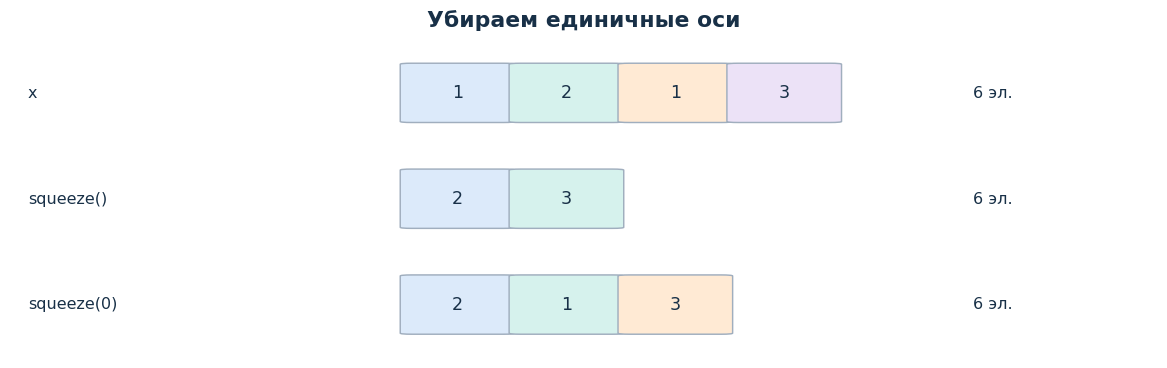

Теперь поговорим про типы данных в тензорах. По умолчанию в тензорах лежат числа в torch.float32 для вещественных и torch.int64 для целочисленных.

In [40]:
tensor = torch.tensor([1.5, 2.2, 3.7, 4.9])

tensor

tensor([1.5000, 2.2000, 3.7000, 4.9000])

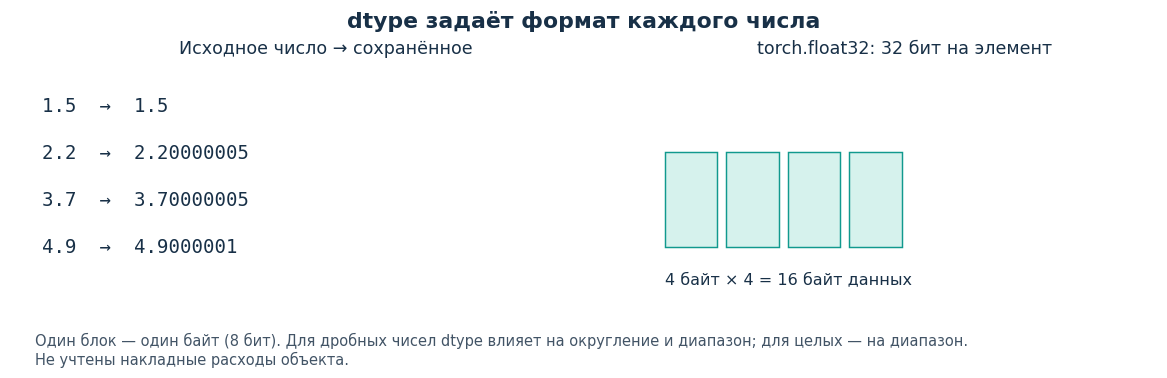

In [41]:
tensor.dtype

torch.float32

In [45]:
tensor = torch.tensor([1.5, 2.2, 3.7, 4.9], dtype=torch.float16)

tensor

tensor([1.5000, 2.1992, 3.6992, 4.8984], dtype=torch.float16)

In [46]:
tensor = torch.tensor([1.5, 2.2, 3.7, 4.9], dtype=torch.bfloat16)

tensor

tensor([1.5000, 2.2031, 3.7031, 4.9062], dtype=torch.bfloat16)

In [43]:
tensor = torch.tensor([1.5, 2.2, 3.7, 4.9], dtype=torch.float64)

tensor

tensor([1.5000, 2.2000, 3.7000, 4.9000], dtype=torch.float64)

In [42]:
tensor = torch.tensor([15, 22, 37, 49])

tensor

tensor([15, 22, 37, 49])

In [43]:
tensor.dtype

torch.int64

In [44]:
tensor = torch.tensor([15, 22, 37, 49], dtype=torch.int32)

tensor

tensor([15, 22, 37, 49], dtype=torch.int32)

In [45]:
tensor = torch.tensor([15, 22, 37, 49], dtype=torch.int16)

tensor

tensor([15, 22, 37, 49], dtype=torch.int16)

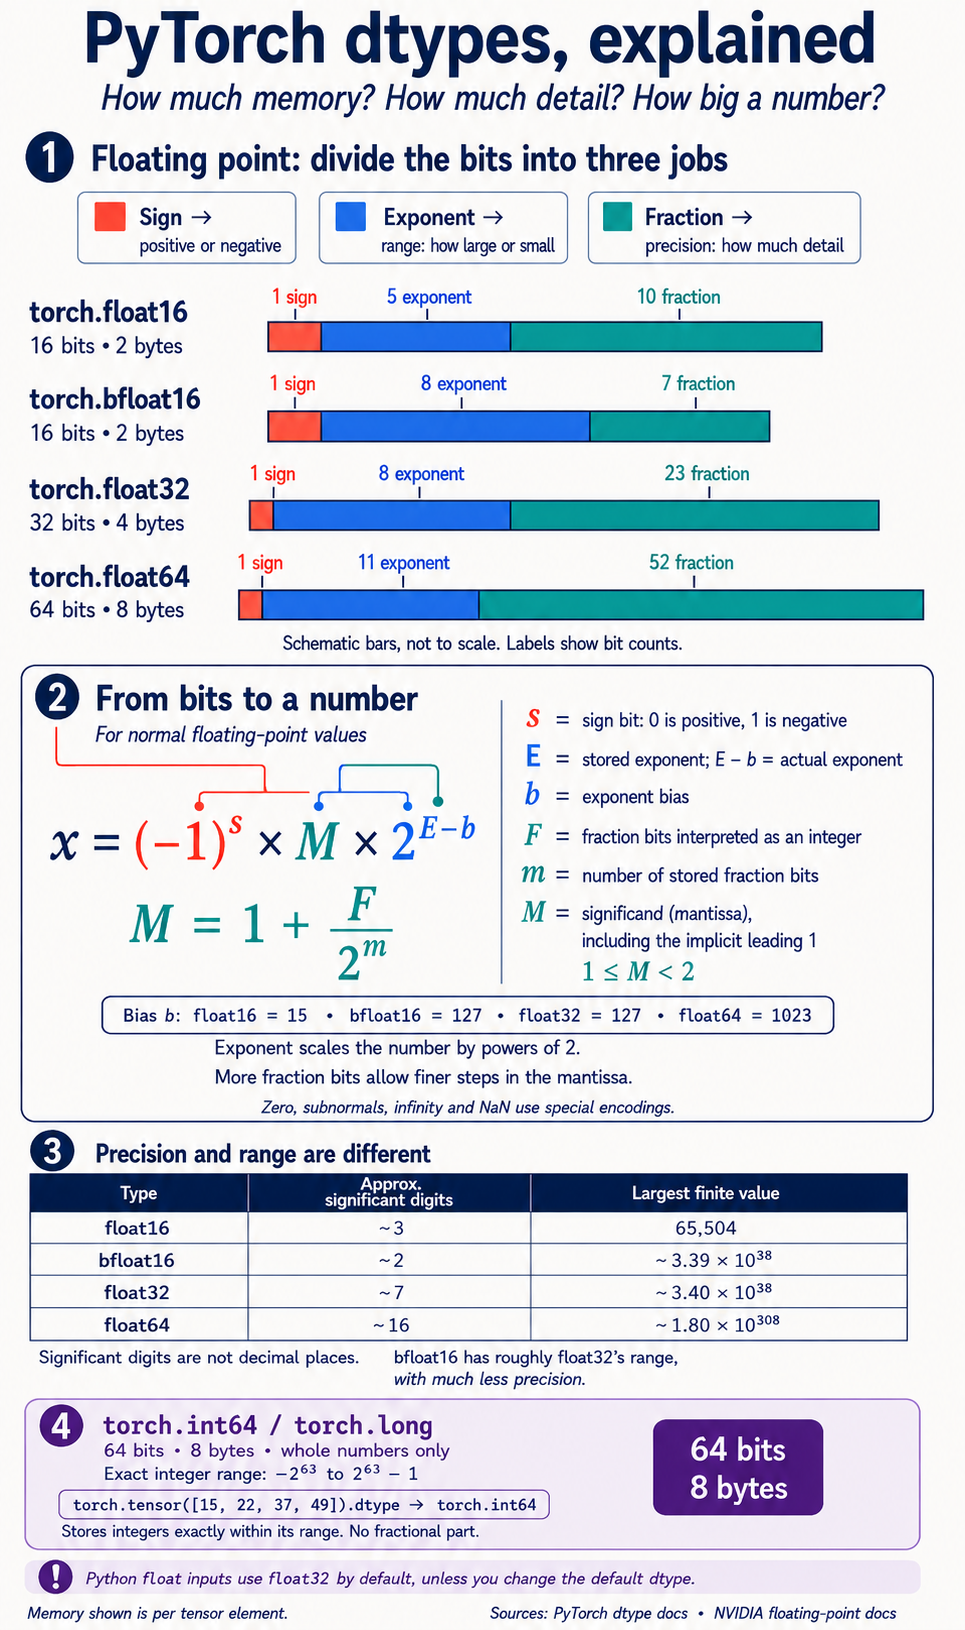

Размещение тензора на GPU:

In [46]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
NVIDIA A100-SXM4-80GB


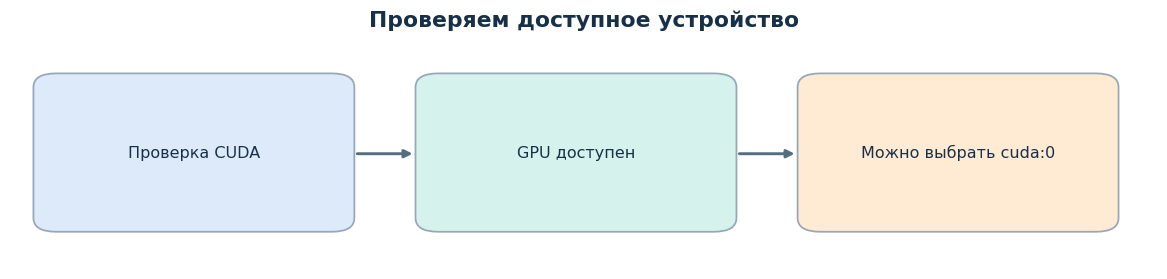

In [53]:
device = torch.device('cuda:5' if torch.cuda.is_available() else 'cpu')

print(device)

cuda:5


In [54]:
tensor = torch.tensor([15, 22, 37, 49], device=device)

tensor

tensor([15, 22, 37, 49], device='cuda:5')

In [55]:
tensor = torch.tensor([15, 22, 37, 49])

print(tensor)

tensor = tensor.to(device)

tensor

tensor([15, 22, 37, 49])


tensor([15, 22, 37, 49], device='cuda:5')

In [56]:
tensor.to(torch.int32)

tensor([15, 22, 37, 49], device='cuda:5', dtype=torch.int32)

In [57]:
tensor = tensor.cpu()

tensor

tensor([15, 22, 37, 49])

In [58]:
tensor.cuda()

tensor([15, 22, 37, 49], device='cuda:0')

In [59]:
tensor.device

device(type='cpu')

In [60]:
a = torch.rand(2, 3)
b = torch.rand(2, 3)

a + b

tensor([[1.7009, 1.3687, 0.8726],
        [1.2681, 0.3034, 0.8740]])

In [61]:
a = a.to(device)

a + b

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:5 and cpu!

In [62]:
b = b.to(device)

a + b

tensor([[1.7009, 1.3687, 0.8726],
        [1.2681, 0.3034, 0.8740]], device='cuda:5')

### Операции с тензорами

Большая часть операций с тензорами хорошо описана в их [документации](https://pytorch.org/docs/stable/torch.html), разберем основные:

In [63]:
a = torch.rand(2, 3)
b = torch.rand(2, 3)

a, b

(tensor([[0.4521, 0.4887, 0.4945],
         [0.3844, 0.6748, 0.7669]]),
 tensor([[0.1106, 0.5198, 0.2136],
         [0.5454, 0.4868, 0.9602]]))

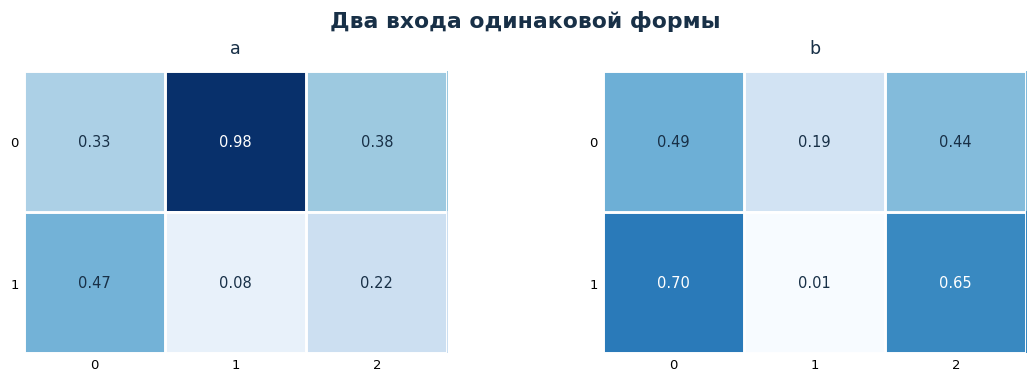

In [64]:
# поэлементные

print(a + b)

print()

print(torch.add(a, b))

print()

print(a.add(b))

tensor([[0.5627, 1.0085, 0.7080],
        [0.9298, 1.1616, 1.7271]])

tensor([[0.5627, 1.0085, 0.7080],
        [0.9298, 1.1616, 1.7271]])

tensor([[0.5627, 1.0085, 0.7080],
        [0.9298, 1.1616, 1.7271]])


In [65]:
print(a - b)

print()

print(torch.sub(a, b))

print()

print(a.sub(b))

tensor([[ 0.3415, -0.0311,  0.2809],
        [-0.1610,  0.1880, -0.1933]])

tensor([[ 0.3415, -0.0311,  0.2809],
        [-0.1610,  0.1880, -0.1933]])

tensor([[ 0.3415, -0.0311,  0.2809],
        [-0.1610,  0.1880, -0.1933]])


In [66]:
print(a * b)

print()

print(torch.mul(a, b))

print()

print(a.mul(b))

tensor([[0.0500, 0.2540, 0.1056],
        [0.2096, 0.3285, 0.7364]])

tensor([[0.0500, 0.2540, 0.1056],
        [0.2096, 0.3285, 0.7364]])

tensor([[0.0500, 0.2540, 0.1056],
        [0.2096, 0.3285, 0.7364]])


In [67]:
print(a / b)

print()

print(torch.div(a, b))

print()

print(a.div(b))

tensor([[4.0872, 0.9401, 2.3153],
        [0.7048, 1.3862, 0.7987]])

tensor([[4.0872, 0.9401, 2.3153],
        [0.7048, 1.3862, 0.7987]])

tensor([[4.0872, 0.9401, 2.3153],
        [0.7048, 1.3862, 0.7987]])


In [68]:
a = torch.rand(2, 3)
b = torch.rand(3, 4)
c = torch.rand(5, 5)

a, b, c

(tensor([[0.2609, 0.3701, 0.9391],
         [0.2231, 0.1149, 0.3412]]),
 tensor([[0.9674, 0.3914, 0.8172, 0.6143],
         [0.6968, 0.9142, 0.8403, 0.0137],
         [0.8929, 0.0180, 0.9570, 0.3964]]),
 tensor([[0.2031, 0.1007, 0.6660, 0.5565, 0.2328],
         [0.3216, 0.5574, 0.4648, 0.4867, 0.2823],
         [0.6515, 0.0295, 0.1912, 0.4483, 0.9670],
         [0.8769, 0.9785, 0.7872, 0.1037, 0.1000],
         [0.1335, 0.6256, 0.5519, 0.2257, 0.8724]]))

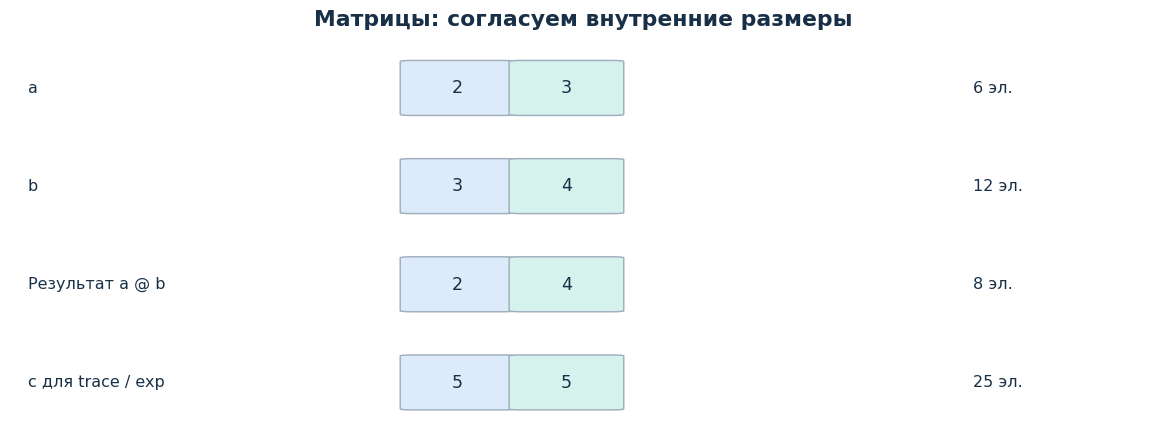

In [70]:
# матричные операции

print(a @ b, (a @ b).shape)

print()

print(torch.matmul(a, b), torch.matmul(a, b).shape)

print()

print(c.trace())

print()

print(c.exp())

tensor([[1.3489, 0.4574, 1.4230, 0.5377],
        [0.6005, 0.1984, 0.6053, 0.2738]]) torch.Size([2, 4])

tensor([[1.3489, 0.4574, 1.4230, 0.5377],
        [0.6005, 0.1984, 0.6053, 0.2738]]) torch.Size([2, 4])

tensor(1.9279)

tensor([[1.2253, 1.1060, 1.9465, 1.7446, 1.2621],
        [1.3793, 1.7460, 1.5917, 1.6270, 1.3261],
        [1.9185, 1.0300, 1.2107, 1.5657, 2.6299],
        [2.4035, 2.6603, 2.1972, 1.1093, 1.1052],
        [1.1428, 1.8695, 1.7365, 1.2532, 2.3927]])


### [Автоматическое дифференцирование](https://pytorch.org/docs/stable/notes/autograd.html)

In [71]:
x = torch.rand(5)

x

tensor([0.0195, 0.0166, 0.5032, 0.5205, 0.4531])

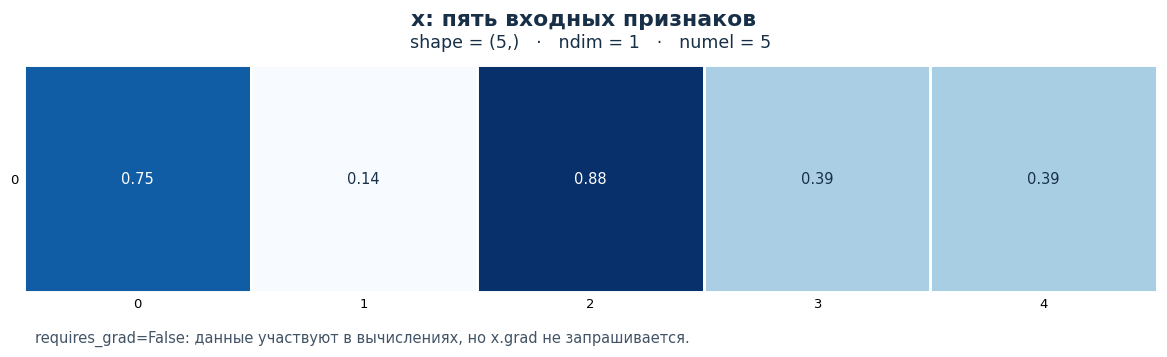

In [72]:
w = torch.rand(3, 5, requires_grad=True)

w

tensor([[0.5096, 0.0290, 0.4068, 0.3167, 0.0228],
        [0.3913, 0.8945, 0.5715, 0.4863, 0.6343],
        [0.4142, 0.7488, 0.6467, 0.6276, 0.5169]], requires_grad=True)

In [73]:
print(w.grad)

None


In [74]:
first_z = torch.empty(3)

first_z

tensor([-2.7632e-37,  4.5591e-41,  2.0390e-26])

In [75]:
for i in range(3):
    first_z[i] = torch.sum(w[i] * x)

first_z

tensor([0.3903, 0.8505, 0.9068], grad_fn=<CopySlices>)

In [76]:
z = torch.matmul(x, w.t())

z

tensor([0.3903, 0.8505, 0.9068], grad_fn=<SqueezeBackward4>)

In [77]:
v = torch.rand(3, requires_grad=True)

v

tensor([0.3479, 0.6663, 0.7142], requires_grad=True)

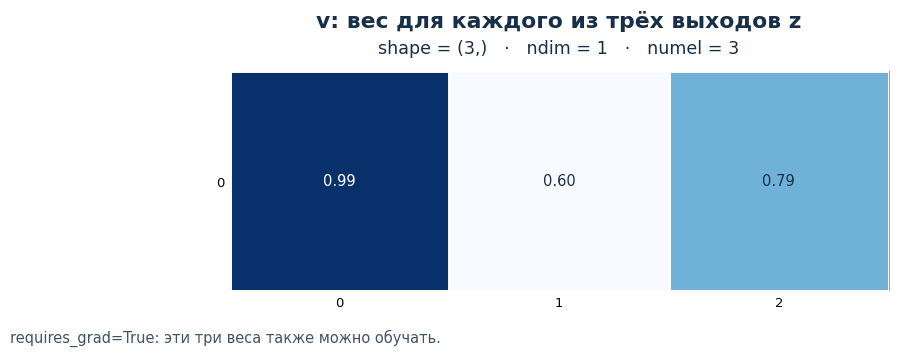

In [78]:
print(v.grad)

None


In [79]:
y = torch.sum(z * v)

y

tensor(1.3500, grad_fn=<SumBackward0>)

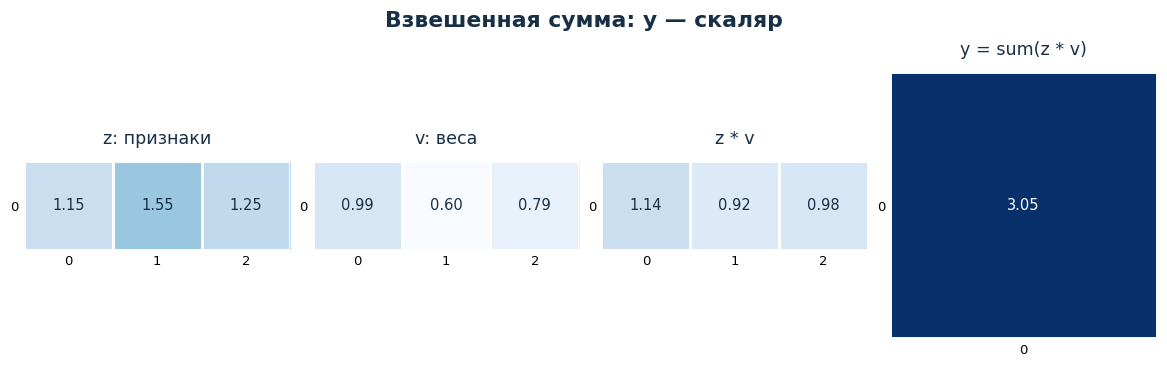

In [80]:
w[0,0]

tensor(0.5096, grad_fn=<SelectBackward0>)

In [81]:
y.item()

1.3500359058380127

In [82]:
loss = torch.mean((y - 2) ** 2)

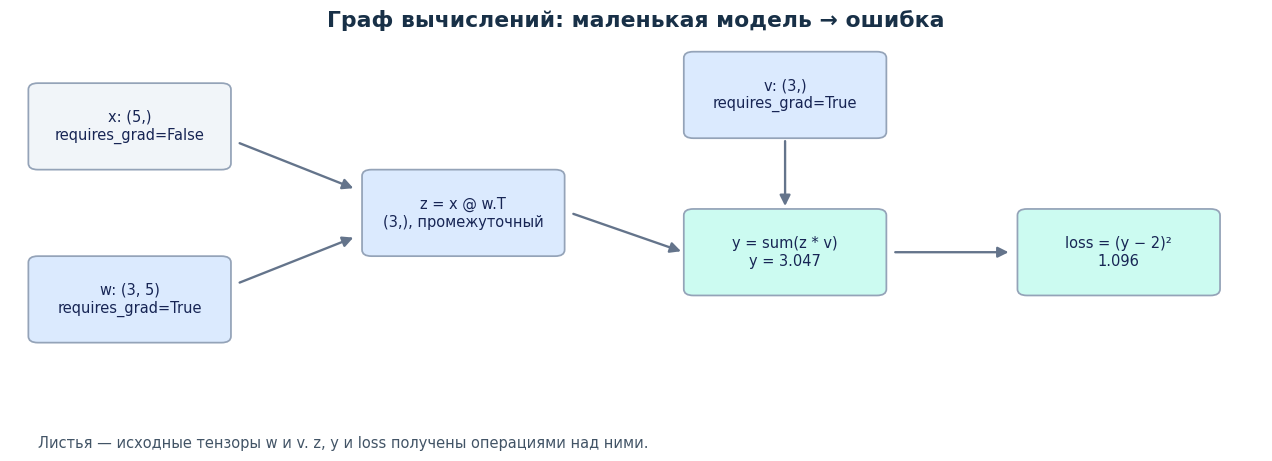

In [84]:
loss

tensor(0.4225, grad_fn=<MeanBackward0>)

In [85]:
print(f'{x.grad=}\n')
print(f'{w.grad=}\n')
print(f'{z.grad=}\n')
print(f'{v.grad=}\n')

x.grad=None

w.grad=None

z.grad=None

v.grad=None



/var/tmp/ipykernel_3147394/162867685.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  print(f'{z.grad=}\n')


In [86]:
loss.backward()

In [87]:
print(f'{x.grad=}\n')
print(f'{w.grad=}\n')
print(f'{z.grad=}\n')
print(f'{v.grad=}\n')

x.grad=None

w.grad=tensor([[-0.0088, -0.0075, -0.2276, -0.2354, -0.2049],
        [-0.0168, -0.0144, -0.4358, -0.4508, -0.3924],
        [-0.0181, -0.0154, -0.4672, -0.4832, -0.4206]])

z.grad=None

v.grad=tensor([-0.5074, -1.1056, -1.1787])



/var/tmp/ipykernel_3147394/162867685.py:3: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  print(f'{z.grad=}\n')


=================================================================================================

In [88]:
a = torch.rand(1, requires_grad=True)
b = torch.rand(1, requires_grad=True)

a, b

(tensor([0.0425], requires_grad=True), tensor([0.0319], requires_grad=True))

In [89]:
loss = (a - b)

loss

tensor([0.0105], grad_fn=<SubBackward0>)

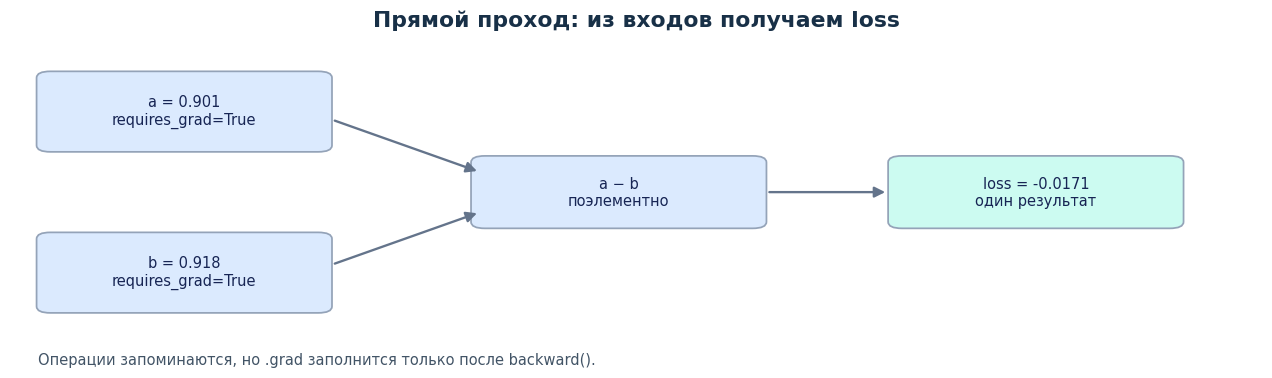

In [90]:
print(f'{a.grad=}\n')
print(f'{b.grad=}\n')

a.grad=None

b.grad=None



In [91]:
loss.backward()

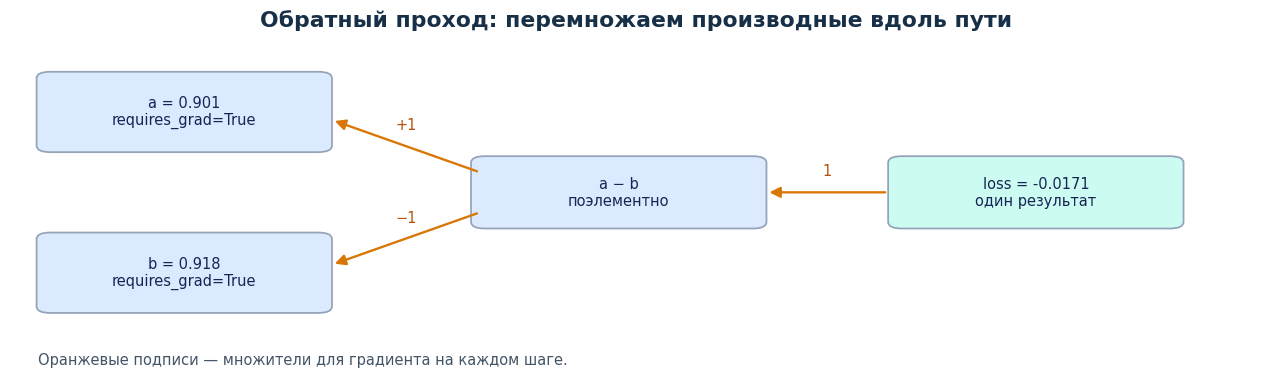

In [92]:
print(f'{a.grad=}\n')  # 1
print(f'{b.grad=}\n')  # -1

a.grad=tensor([1.])

b.grad=tensor([-1.])



=================================================================================================

In [93]:
a.grad.zero_()
b.grad.zero_()

tensor([0.])

In [94]:
print(f'{a.grad=}\n')  # 1
print(f'{b.grad=}\n')  # -1

a.grad=tensor([0.])

b.grad=tensor([0.])



In [95]:
loss = (a - b) ** 2

loss

tensor([0.0001], grad_fn=<PowBackward0>)

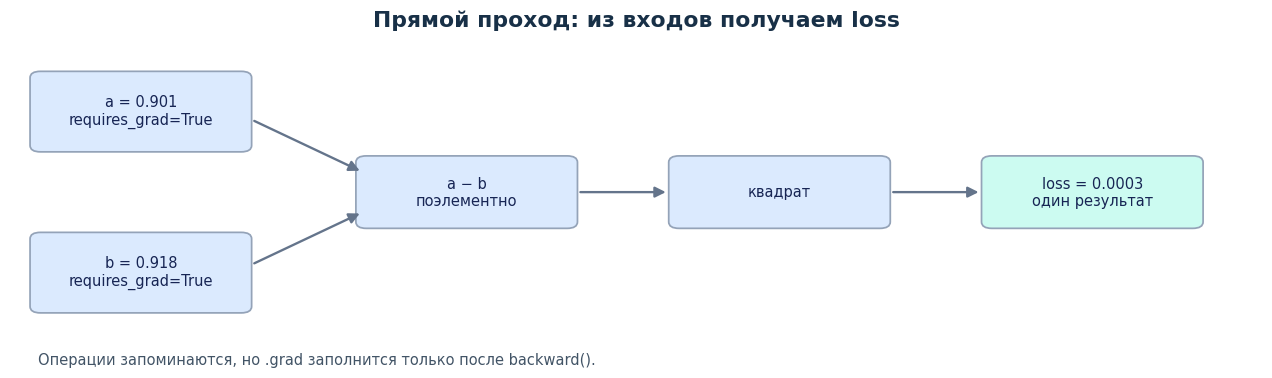

In [96]:
print(f'{a.grad=}\n')
print(f'{b.grad=}\n')

a.grad=tensor([0.])

b.grad=tensor([0.])



In [97]:
loss.backward()

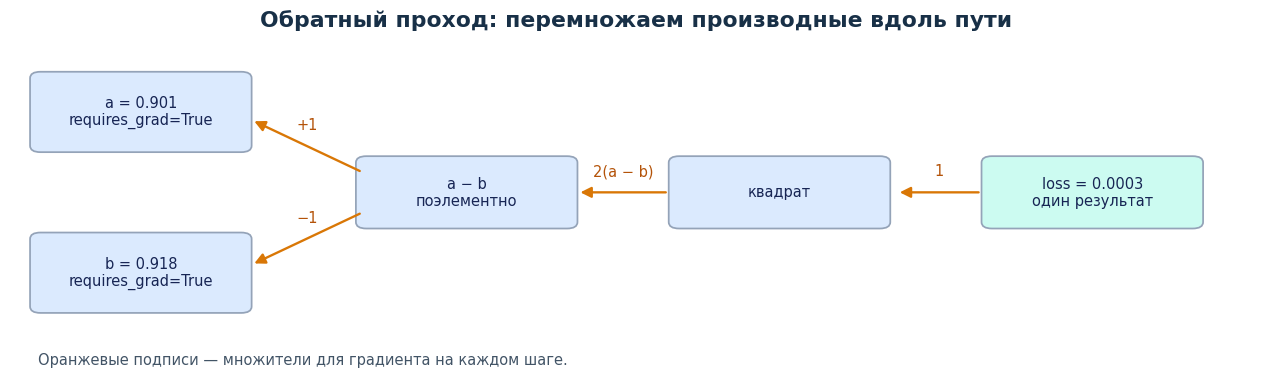


In [98]:
print(f'{a.grad=}\n')  # 2 * (a - b)
print(f'{b.grad=}\n')  # -2 * (a - b)

a.grad=tensor([0.0210])

b.grad=tensor([-0.0210])



In [99]:
2 * (a - b)

tensor([0.0210], grad_fn=<MulBackward0>)

=================================================================================================

In [100]:
a = torch.rand(3, 5, requires_grad=True)
b = torch.rand(3, 5, requires_grad=True)

a, b

(tensor([[0.5058, 0.1899, 0.0518, 0.2086, 0.5390],
         [0.7126, 0.9098, 0.9937, 0.9485, 0.2898],
         [0.0178, 0.0654, 0.8108, 0.8771, 0.0252]], requires_grad=True),
 tensor([[0.1149, 0.8701, 0.7002, 0.4522, 0.2222],
         [0.3437, 0.4302, 0.3953, 0.7135, 0.0710],
         [0.5781, 0.5493, 0.8852, 0.5462, 0.7763]], requires_grad=True))

In [101]:
loss = torch.mean(a * b)

loss

tensor(0.2308, grad_fn=<MeanBackward0>)

In [102]:
print(f'{a.grad=}\n')
print(f'{b.grad=}\n')

a.grad=None

b.grad=None



In [103]:
loss.backward()

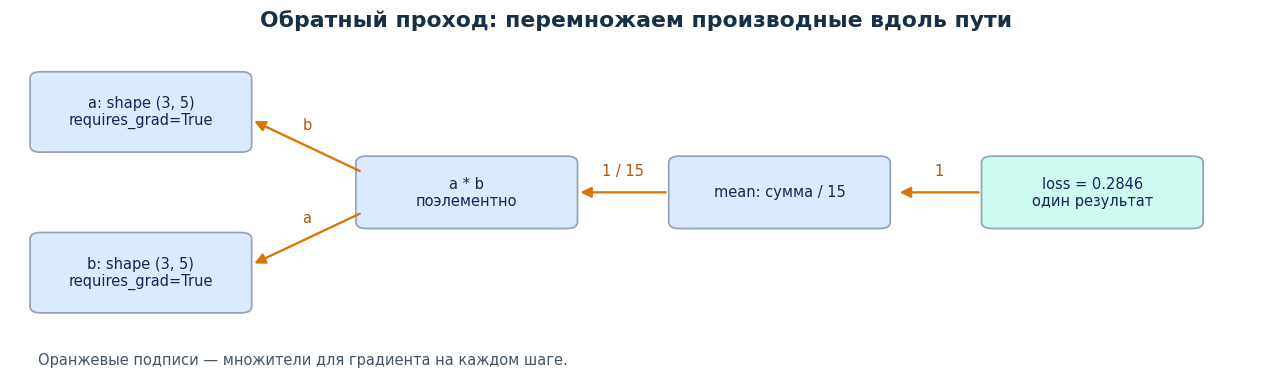

In [104]:
print(f'{a.grad=}\n')  # b / (3 * 5)
print(f'{b.grad=}\n')  # a / (3 * 5)

a.grad=tensor([[0.0077, 0.0580, 0.0467, 0.0301, 0.0148],
        [0.0229, 0.0287, 0.0264, 0.0476, 0.0047],
        [0.0385, 0.0366, 0.0590, 0.0364, 0.0518]])

b.grad=tensor([[0.0337, 0.0127, 0.0035, 0.0139, 0.0359],
        [0.0475, 0.0607, 0.0662, 0.0632, 0.0193],
        [0.0012, 0.0044, 0.0541, 0.0585, 0.0017]])



In [105]:
a / 15

tensor([[0.0337, 0.0127, 0.0035, 0.0139, 0.0359],
        [0.0475, 0.0607, 0.0662, 0.0632, 0.0193],
        [0.0012, 0.0044, 0.0541, 0.0585, 0.0017]], grad_fn=<DivBackward0>)

In [106]:
b / 15

tensor([[0.0077, 0.0580, 0.0467, 0.0301, 0.0148],
        [0.0229, 0.0287, 0.0264, 0.0476, 0.0047],
        [0.0385, 0.0366, 0.0590, 0.0364, 0.0518]], grad_fn=<DivBackward0>)

=================================================================================================

In [108]:
a = torch.rand(3, 5, requires_grad=True)

print(f'{a=}\n')

loss1 = torch.sum(a ** 2) # 2a
loss2 = torch.sum(a) # 1

print(f'{a.grad=}\n')

loss1.backward()

print(f'{a.grad=}\n')

a.grad.zero_()

loss2.backward()

print(f'{a.grad=}\n')

a=tensor([[0.9671, 0.4168, 0.8599, 0.9676, 0.9879],
        [0.5898, 0.1633, 0.2934, 0.8693, 0.8826],
        [0.6860, 0.9649, 0.6511, 0.3754, 0.7484]], requires_grad=True)

a.grad=None

a.grad=tensor([[1.9342, 0.8336, 1.7198, 1.9352, 1.9758],
        [1.1796, 0.3266, 0.5869, 1.7385, 1.7653],
        [1.3720, 1.9297, 1.3023, 0.7508, 1.4969]])

a.grad=tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])



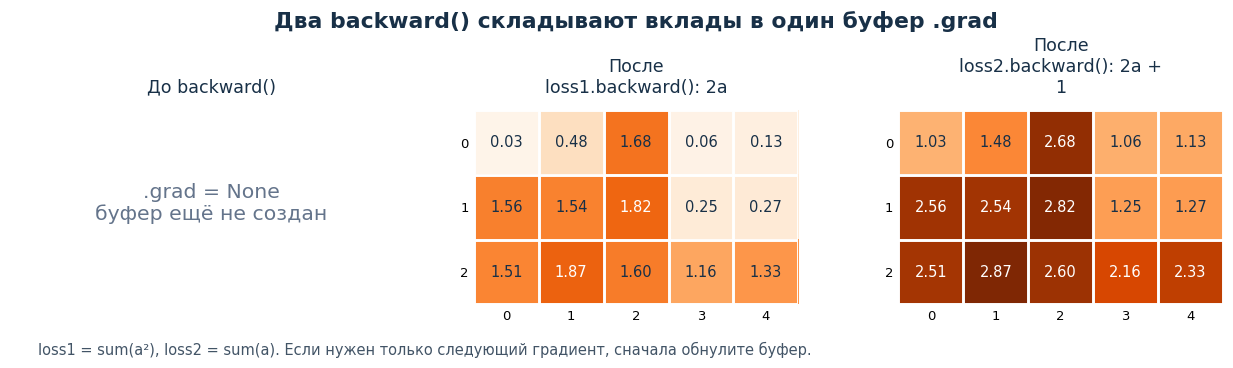

In [109]:
print(f'{2*a=}\n')
print(f'{2*a+1=}')

2*a=tensor([[1.9342, 0.8336, 1.7198, 1.9352, 1.9758],
        [1.1796, 0.3266, 0.5869, 1.7385, 1.7653],
        [1.3720, 1.9297, 1.3023, 0.7508, 1.4969]], grad_fn=<MulBackward0>)

2*a+1=tensor([[2.9342, 1.8336, 2.7198, 2.9352, 2.9758],
        [2.1796, 1.3266, 1.5869, 2.7385, 2.7653],
        [2.3720, 2.9297, 2.3023, 1.7508, 2.4969]], grad_fn=<AddBackward0>)


=================================================================================================

In [110]:
a = torch.rand(3, 5, requires_grad=True)
b = torch.rand(3, 5, requires_grad=False)

a, b

(tensor([[0.5265, 0.3770, 0.9148, 0.8186, 0.2796],
         [0.6322, 0.4351, 0.7344, 0.1749, 0.7567],
         [0.9635, 0.4074, 0.9345, 0.6866, 0.0095]], requires_grad=True),
 tensor([[0.4172, 0.1034, 0.8755, 0.6049, 0.9839],
         [0.4210, 0.9086, 0.6715, 0.6622, 0.8350],
         [0.7894, 0.9749, 0.8556, 0.7894, 0.4611]]))

In [111]:
loss = torch.sum(a - b)

loss

tensor(-1.7021, grad_fn=<SumBackward0>)

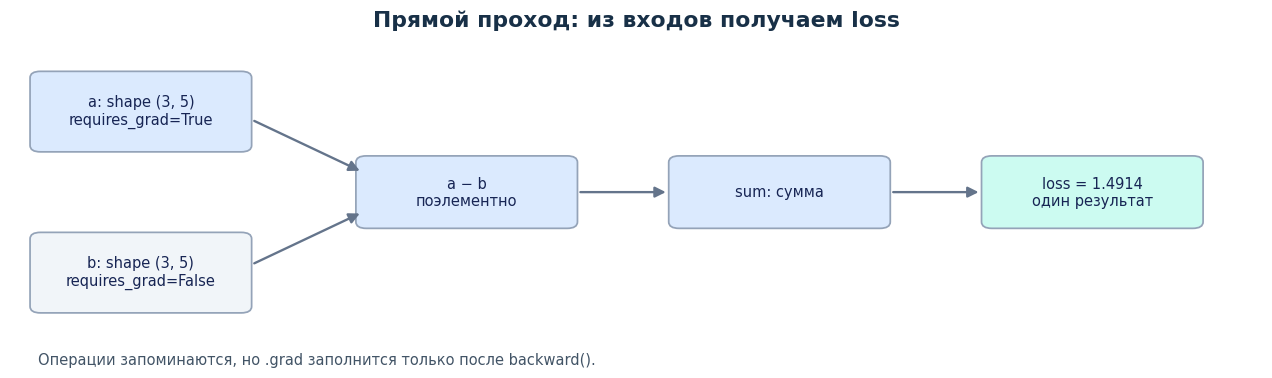

In [112]:
print(f'{a.grad=}\n')
print(f'{b.grad=}\n')

a.grad=None

b.grad=None



In [113]:
loss.backward()

In [114]:
print(f'{a.grad=}\n')  # all ones
print(f'{b.grad=}\n')  # None

a.grad=tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

b.grad=None



=================================================================================================

In [115]:
a = torch.rand(3, 5, requires_grad=True)
b = torch.rand(3, 5, requires_grad=True)

a, b

(tensor([[0.2152, 0.3930, 0.6974, 0.8501, 0.7696],
         [0.6321, 0.1590, 0.2683, 0.4060, 0.2533],
         [0.5662, 0.1627, 0.8706, 0.5414, 0.8917]], requires_grad=True),
 tensor([[0.8613, 0.3729, 0.1483, 0.1633, 0.5550],
         [0.4389, 0.8754, 0.1636, 0.7021, 0.3109],
         [0.0082, 0.5546, 0.8234, 0.9543, 0.2239]], requires_grad=True))

In [116]:
with torch.no_grad():
    loss = torch.sum(a - b)

loss

tensor(0.5206)

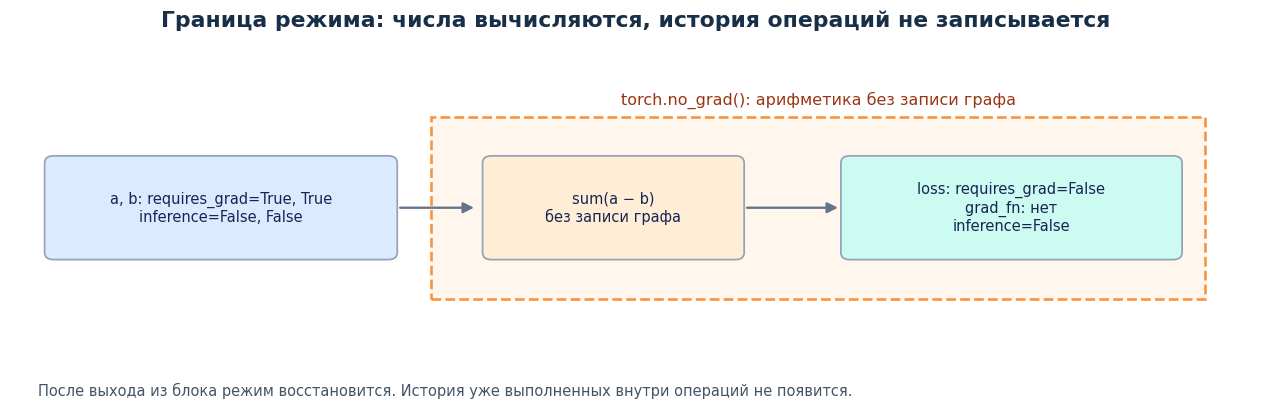

In [117]:
loss = torch.sum(a - b)
loss

tensor(0.5206, grad_fn=<SumBackward0>)

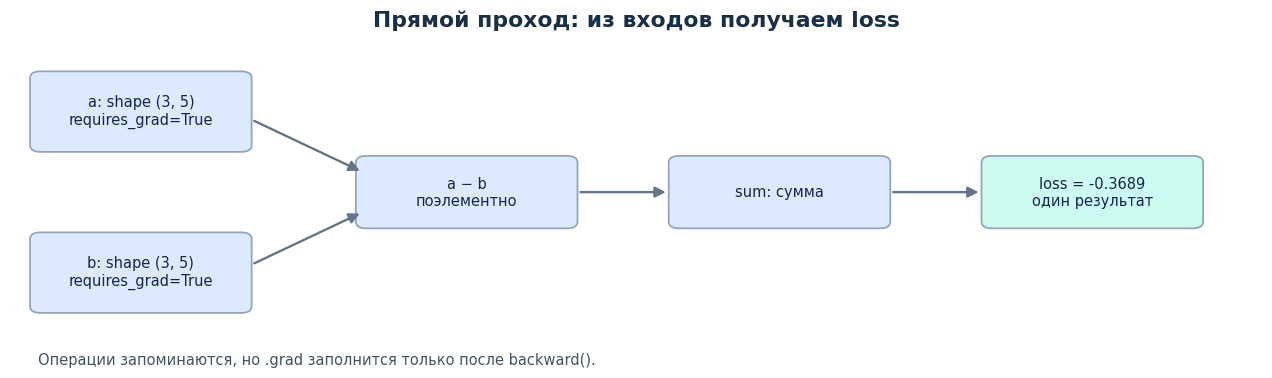

In [119]:
loss.backward()

In [120]:
print(f'{a.grad=}\n')  # all ones
print(f'{b.grad=}\n')  # None

a.grad=tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

b.grad=tensor([[-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]])



=================================================================================================

In [121]:
a = torch.rand(3, 5, requires_grad=True)
b = torch.rand(3, 5, requires_grad=True)

a, b

(tensor([[0.0630, 0.0750, 0.0877, 0.2714, 0.5210],
         [0.3697, 0.5487, 0.4659, 0.5800, 0.8849],
         [0.4432, 0.5651, 0.9276, 0.7760, 0.8916]], requires_grad=True),
 tensor([[0.7135, 0.7426, 0.5103, 0.0621, 0.5661],
         [0.0261, 0.0717, 0.1648, 0.4407, 0.9027],
         [0.8264, 0.2699, 0.3845, 0.3309, 0.0300]], requires_grad=True))

In [122]:
with torch.inference_mode():
    loss = torch.sum(a - b)

loss

tensor(1.4284)

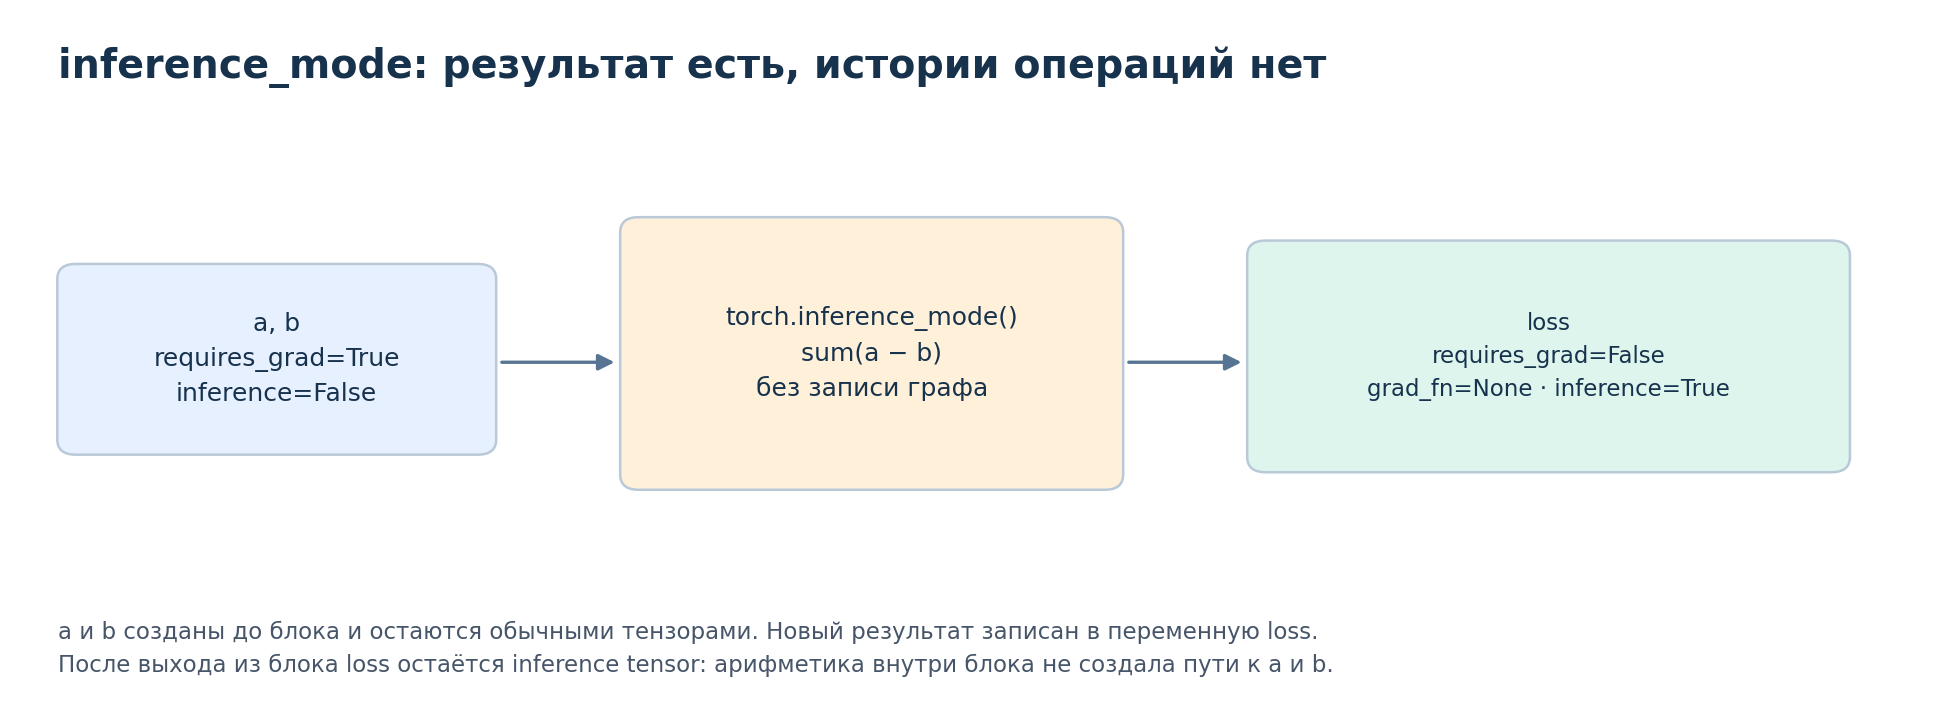

In [124]:
with torch.no_grad():
    loss = torch.sum(a - b)

loss

tensor(1.4284)

In [125]:
loss.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [126]:
with torch.no_grad():
    a = torch.rand(3, 5, requires_grad=True)
    b = torch.rand(3, 5, requires_grad=True)

    loss = torch.sum(a + b)

    print(f'{loss=}')

    loss.backward()

loss=tensor(14.5798)


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [127]:
a

tensor([[0.1891, 0.4313, 0.3978, 0.8650, 0.2157],
        [0.6160, 0.6836, 0.5914, 0.1610, 0.4019],
        [0.5637, 0.9613, 0.0322, 0.8033, 0.0335]], requires_grad=True)

In [129]:
loss2 = torch.sum(a + b)

loss2.backward()

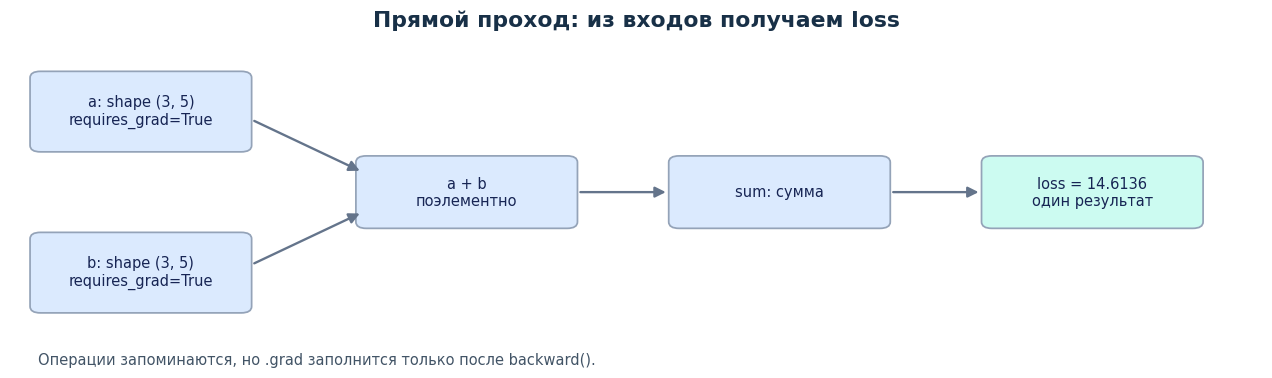

In [137]:
print(f'{a.grad=}\n')
print(f'{b.grad=}\n')

a.grad=None

b.grad=None



In [138]:
loss2.backward()

In [130]:
print(f'{a.grad=}\n')
print(f'{b.grad=}\n')

a.grad=tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])

b.grad=tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])



In [131]:
with torch.inference_mode():
    a = torch.rand(3, 5, requires_grad=True)
    b = torch.rand(3, 5, requires_grad=True)

    loss = torch.sum(a + b)

    print(f'{loss=}')

    loss.backward()

loss=tensor(13.1580)


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [132]:
loss2 = torch.sum(a + b)

loss2

tensor(13.1580)

In [133]:
loss2.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [134]:
@torch.no_grad()
def foo():
    a = torch.rand(3, 5, requires_grad=True)
    b = torch.rand(3, 5, requires_grad=True)

    loss = torch.mean(a + b)

    print(f'{loss=}')

    return a, b

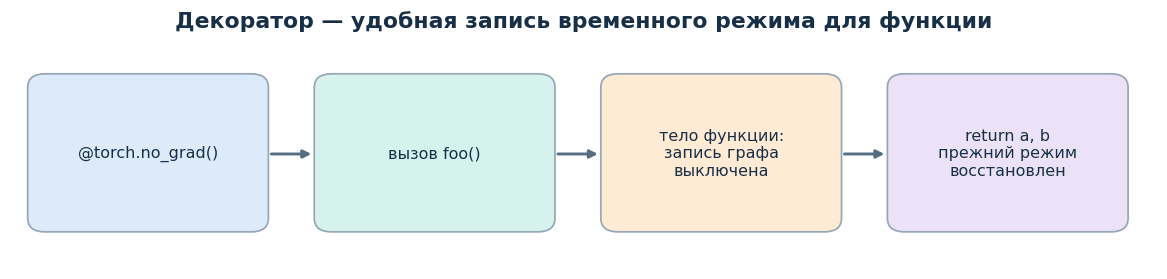

In [135]:
a, b = foo()

loss=tensor(1.1680)


In [136]:
torch.mean(a - b)

tensor(0.0074, grad_fn=<MeanBackward0>)

In [137]:
@torch.inference_mode()
def foo():
    a = torch.rand(3, 5, requires_grad=True)
    b = torch.rand(3, 5, requires_grad=True)

    loss = torch.mean(a + b)

    print(f'{loss=}')

    return a, b

In [138]:
a, b = foo()

loss=tensor(1.0386)


In [139]:
torch.mean(a - b)

tensor(0.0273)

## Полносвязные слои и функции активации в `PyTorch`

In [140]:
from torch import nn

In [141]:
import torch.nn as nn

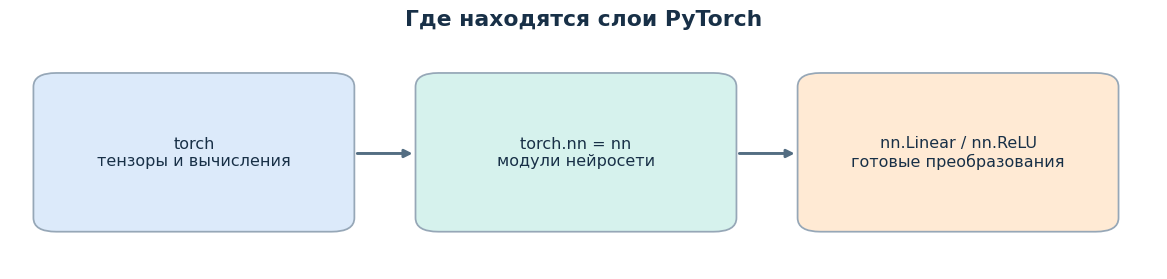

### Полносвязный слой

>$y_j = \sum\limits_{i=1}^{n}x_iw_{ji} + b_j$


In [143]:
layer = nn.Linear(in_features=5, out_features=3)

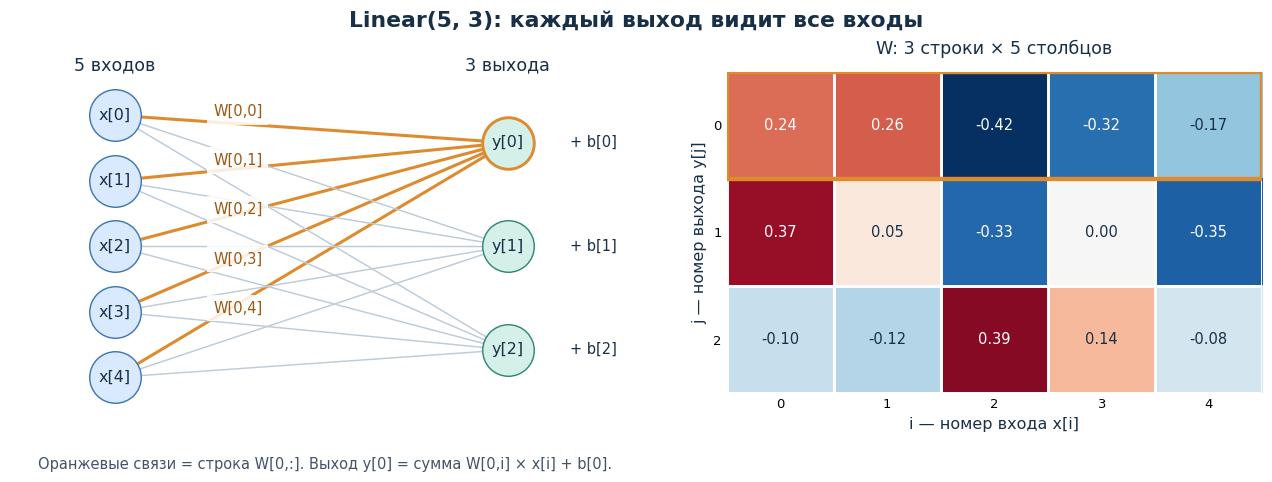

In [144]:
layer

Linear(in_features=5, out_features=3, bias=True)

In [145]:
layer.weight

Parameter containing:
tensor([[-0.1996, -0.1160, -0.3670,  0.2348,  0.4415],
        [ 0.4069,  0.0869, -0.2408,  0.3453, -0.2331],
        [ 0.1313,  0.0490, -0.3745,  0.1049, -0.1430]], requires_grad=True)

In [146]:
layer.weight.data

tensor([[-0.1996, -0.1160, -0.3670,  0.2348,  0.4415],
        [ 0.4069,  0.0869, -0.2408,  0.3453, -0.2331],
        [ 0.1313,  0.0490, -0.3745,  0.1049, -0.1430]])

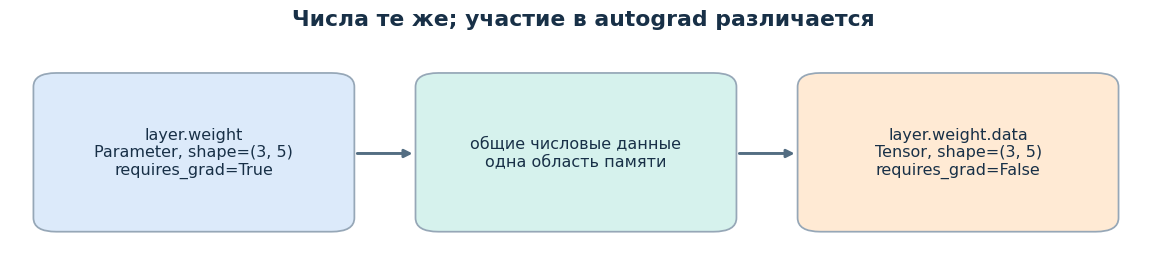

In [149]:
torch.tensor(layer.weight.data, requires_grad=True)

/var/tmp/ipykernel_3147394/1955172637.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(layer.weight.data, requires_grad=True)


tensor([[-0.1996, -0.1160, -0.3670,  0.2348,  0.4415],
        [ 0.4069,  0.0869, -0.2408,  0.3453, -0.2331],
        [ 0.1313,  0.0490, -0.3745,  0.1049, -0.1430]], requires_grad=True)

In [155]:
nn.Parameter(layer.weight.data, requires_grad=True)

Parameter containing:
tensor([[-0.2352, -0.1509, -0.2856, -0.4022,  0.0291],
        [ 0.2902,  0.4073,  0.2610, -0.2318, -0.4423],
        [ 0.1696,  0.2506, -0.3839,  0.1604,  0.3781]], requires_grad=True)

In [151]:
layer.weight.shape

torch.Size([3, 5])

In [152]:
layer.bias

Parameter containing:
tensor([0.3642, 0.4316, 0.0277], requires_grad=True)

In [153]:
layer.bias.shape

torch.Size([3])

In [154]:
layer = nn.Linear(in_features=5, out_features=3, bias=False)

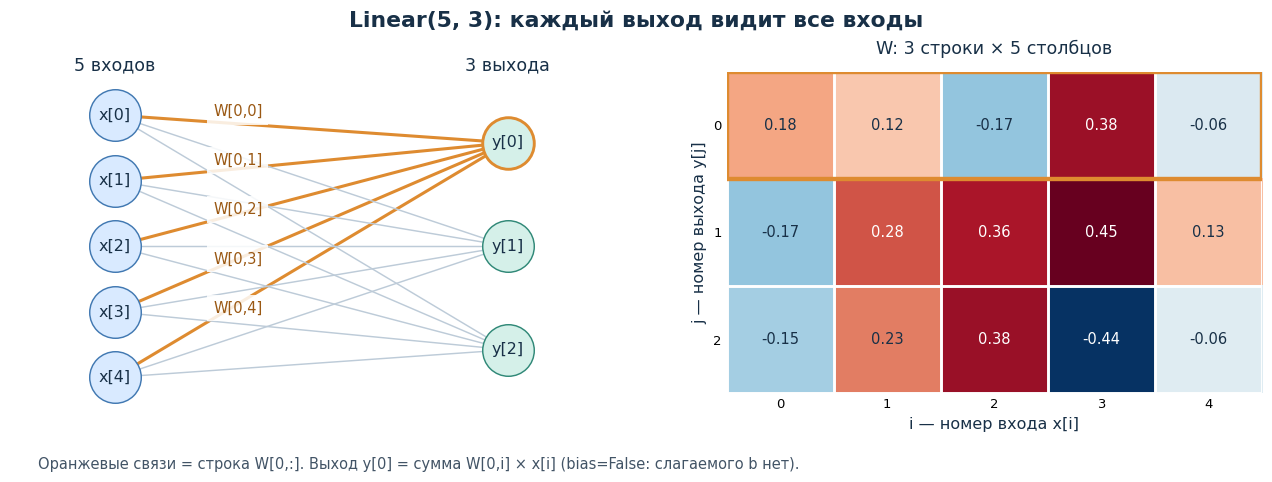

In [155]:
layer.bias is None

True

In [161]:
layer.__call__

<bound method Module._wrapped_call_impl of Linear(in_features=5, out_features=3, bias=False)>

In [156]:
x = torch.randn(5)

print(layer(x))

tensor([0.6373, 0.0279, 0.0233], grad_fn=<SqueezeBackward4>)


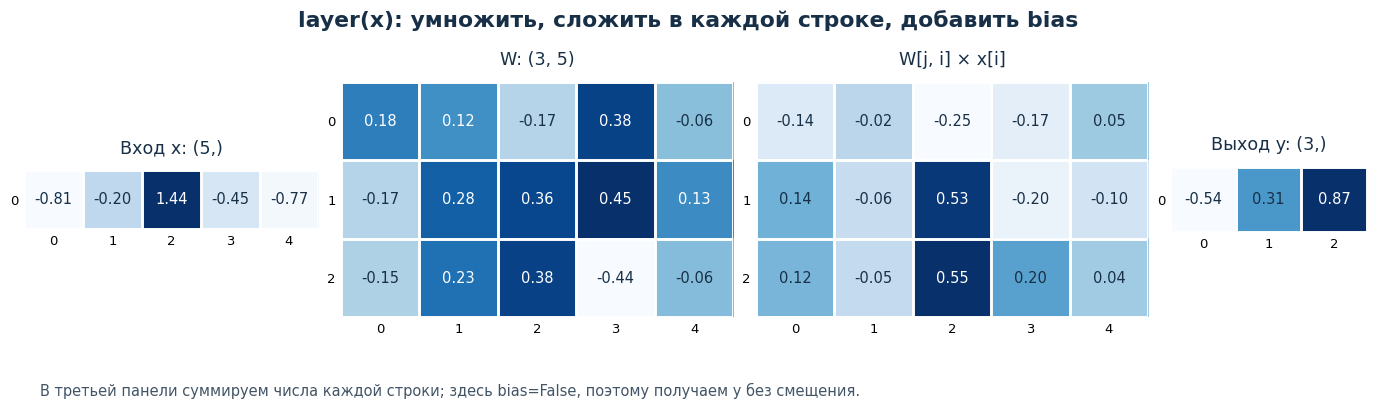

In [157]:
layer1 = nn.Linear(in_features=5, out_features=3)
layer2 = nn.Linear(in_features=3, out_features=1)

layer2(layer1(x))

tensor([1.0411], grad_fn=<ViewBackward0>)

### Функции активации

> Сигмоида $f(x) = \dfrac{1}{1 + e^{-x}}$

In [158]:
activation = nn.Sigmoid()

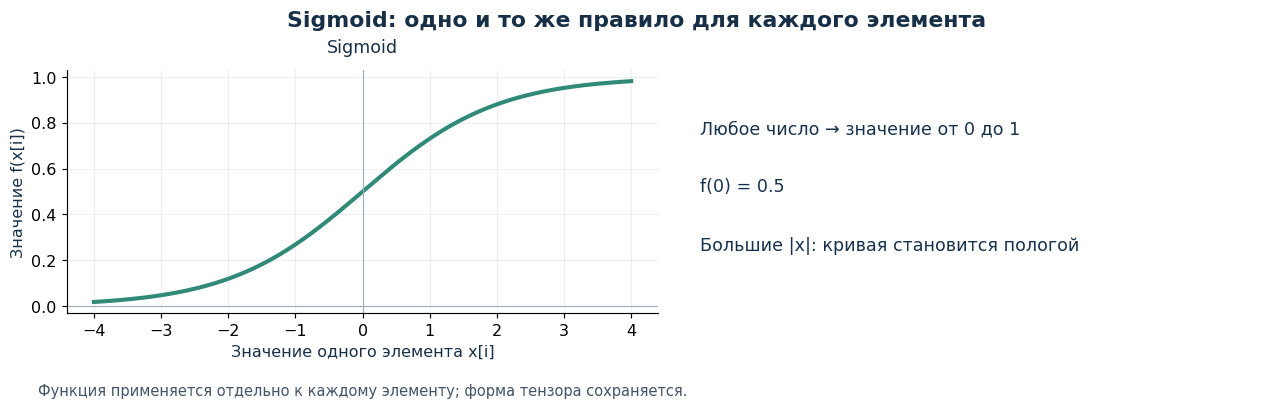

In [159]:
x = torch.randn(5)

print(x)

print(activation(x))

tensor([0.6353, 1.4728, 0.8810, 1.1925, 0.2921])
tensor([0.6537, 0.8135, 0.7070, 0.7672, 0.5725])


> ReLU $f(x) = \max(0, x)$

In [160]:
activation = nn.ReLU()

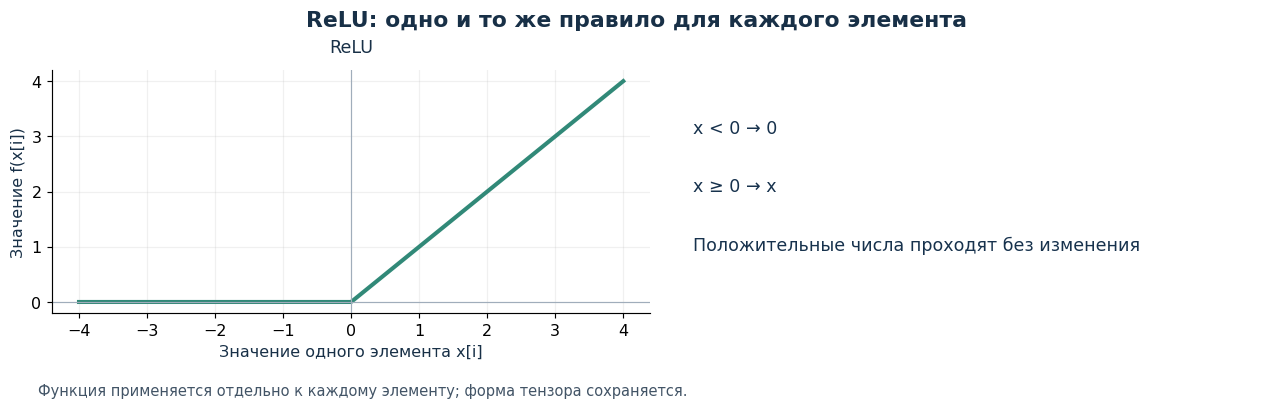

In [161]:
x = torch.randn(5)

print(x)

print(activation(x))

tensor([-2.5030,  1.5126, -2.0593,  1.0533,  1.7379])
tensor([0.0000, 1.5126, 0.0000, 1.0533, 1.7379])


> Leaky ReLU $f(x) = \max(0, x) + \alpha \min(0, x)$

In [162]:
activation = nn.LeakyReLU(negative_slope=0.001)

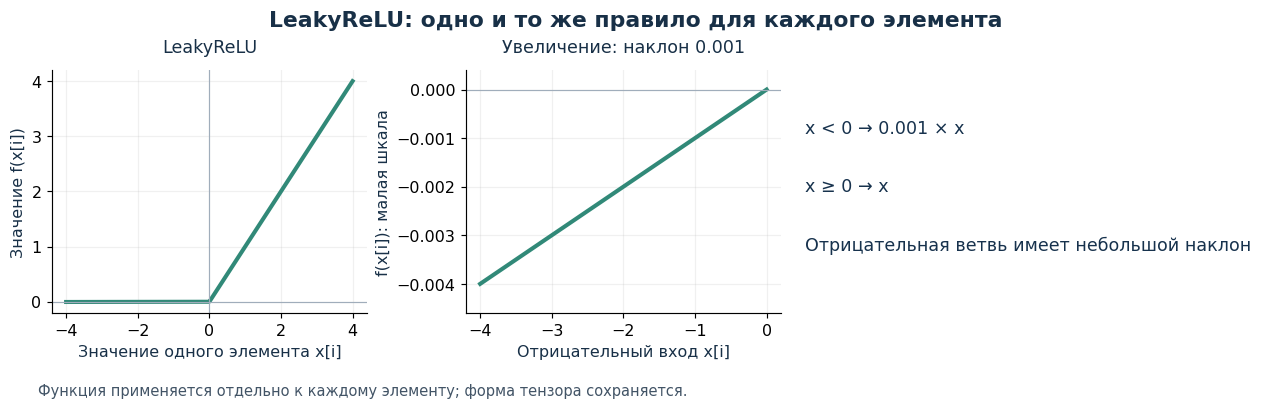

In [163]:
x = torch.randn(5)

print(x)

print(activation(x))

tensor([ 1.6811, -0.3002,  1.0648,  0.8090,  0.5046])
tensor([ 1.6811e+00, -3.0016e-04,  1.0648e+00,  8.0899e-01,  5.0458e-01])


In [164]:
layer1 = nn.Linear(in_features=5, out_features=3)
activation = nn.LeakyReLU(negative_slope=0.001)
layer2 = nn.Linear(in_features=3, out_features=1)

layer2(activation(layer1(x)))

tensor([0.2148], grad_fn=<ViewBackward0>)

## Градиентный спуск своими руками

In [165]:
n_features = 2
n_objects = 300

torch.manual_seed(0)

w_true = torch.randn(n_features)
b_true = torch.randn(1)

x = (torch.rand(n_objects, n_features) - 0.5) * 10 * (torch.arange(n_features) * 2 + 1)
y = torch.matmul(x, w_true) + torch.randn(n_objects) + b_true

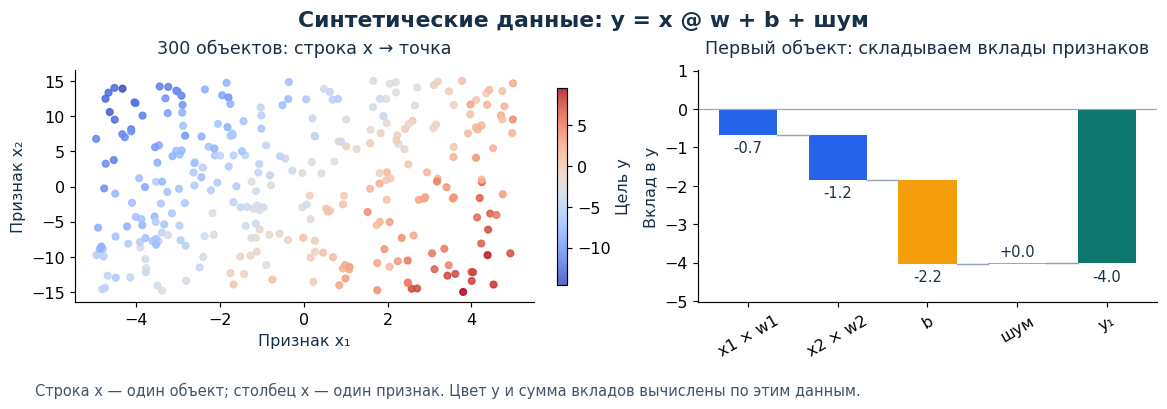

In [166]:
x.shape

torch.Size([300, 2])

In [167]:
y.shape

torch.Size([300])

In [169]:
n_steps = 200
step_size = 1e-2

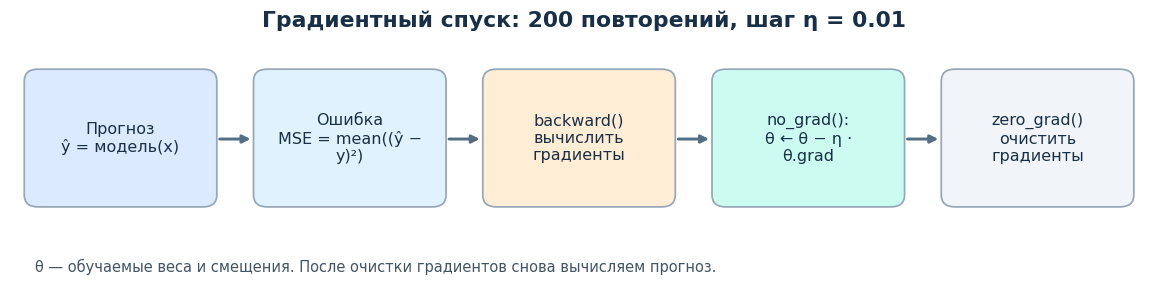

In [170]:
w = torch.rand(n_features, requires_grad=True)
b = torch.rand(1, requires_grad=True)

for i in range(n_steps):
    y_pred = torch.matmul(x, w) + b

    mse = torch.mean((y_pred - y) ** 2)

    if i < 20 or i % 10 == 0:
        print(f'MSE на шаге {i + 1} {mse.item():.5f}')

    mse.backward()

    with torch.no_grad():
        w -= w.grad * step_size
        b -= b.grad * step_size

    w.grad.zero_()
    b.grad.zero_()

MSE на шаге 1 130.75197
MSE на шаге 2 53.79208
MSE на шаге 3 27.54351
MSE на шаге 4 17.58543
MSE на шаге 5 13.15989
MSE на шаге 6 10.80943
MSE на шаге 7 9.35913
MSE на шаге 8 8.36826
MSE на шаге 9 7.64593
MSE на шаге 10 7.09519
MSE на шаге 11 6.65989
MSE на шаге 12 6.30461
MSE на шаге 13 6.00597
MSE на шаге 14 5.74817
MSE на шаге 15 5.52038
MSE на шаге 16 5.31513
MSE на шаге 17 5.12724
MSE на шаге 18 4.95309
MSE на шаге 19 4.79012
MSE на шаге 20 4.63651
MSE на шаге 21 4.49096
MSE на шаге 31 3.34447
MSE на шаге 41 2.58160
MSE на шаге 51 2.06947
MSE на шаге 61 1.72556
MSE на шаге 71 1.49461
MSE на шаге 81 1.33952
MSE на шаге 91 1.23537
MSE на шаге 101 1.16543
MSE на шаге 111 1.11847
MSE на шаге 121 1.08693
MSE на шаге 131 1.06575
MSE на шаге 141 1.05153
MSE на шаге 151 1.04197
MSE на шаге 161 1.03556
MSE на шаге 171 1.03125
MSE на шаге 181 1.02836
MSE на шаге 191 1.02642


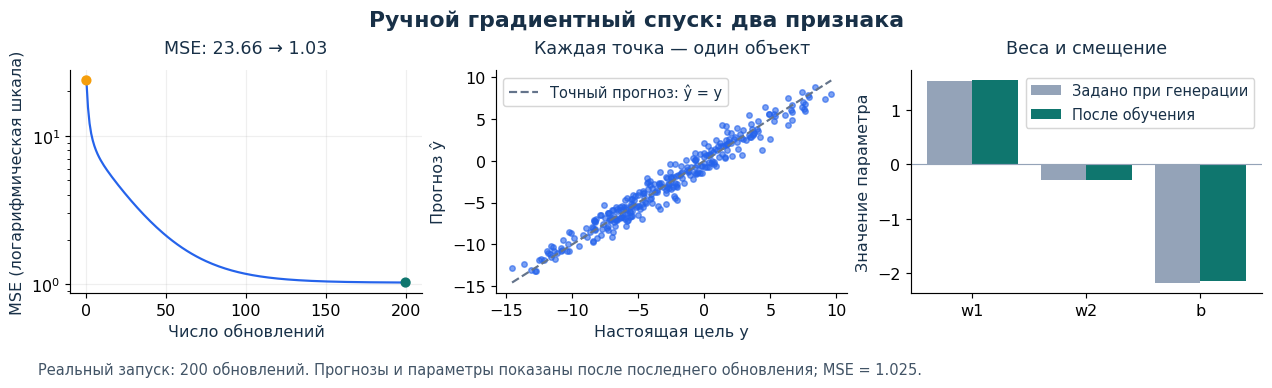

In [171]:
layer = nn.Linear(in_features=n_features, out_features=1)

for i in range(n_steps):
    y_pred = layer(x)

    mse = torch.mean((y_pred - y) ** 2)

    if i < 20 or i % 10 == 0:
        print(f'MSE на шаге {i + 1} {mse.item():.5f}')

    mse.backward()

    with torch.no_grad():
        layer.weight -= layer.weight.grad * step_size
        layer.bias -= layer.bias.grad * step_size

    layer.zero_grad()

MSE на шаге 1 67.76115
MSE на шаге 2 42.90440
MSE на шаге 3 34.78294
MSE на шаге 4 31.90576
MSE на шаге 5 30.72448
MSE на шаге 6 30.12742
MSE на шаге 7 29.75548
MSE на шаге 8 29.48539
MSE на шаге 9 29.27014
MSE на шаге 10 29.08890
MSE на шаге 11 28.93083
MSE на шаге 12 28.78951
MSE на шаге 13 28.66082
MSE на шаге 14 28.54199
MSE на шаге 15 28.43109
MSE на шаге 16 28.32677
MSE на шаге 17 28.22807
MSE на шаге 18 28.13428
MSE на шаге 19 28.04487
MSE на шаге 20 27.95945
MSE на шаге 21 27.87770
MSE на шаге 31 27.22173
MSE на шаге 41 26.78238
MSE на шаге 51 26.48738
MSE на шаге 61 26.28927
MSE на шаге 71 26.15623
MSE на шаге 81 26.06689
MSE на шаге 91 26.00690
MSE на шаге 101 25.96661
MSE на шаге 111 25.93955
MSE на шаге 121 25.92138
MSE на шаге 131 25.90918
MSE на шаге 141 25.90099
MSE на шаге 151 25.89549
MSE на шаге 161 25.89179
MSE на шаге 171 25.88931
MSE на шаге 181 25.88764
MSE на шаге 191 25.88653


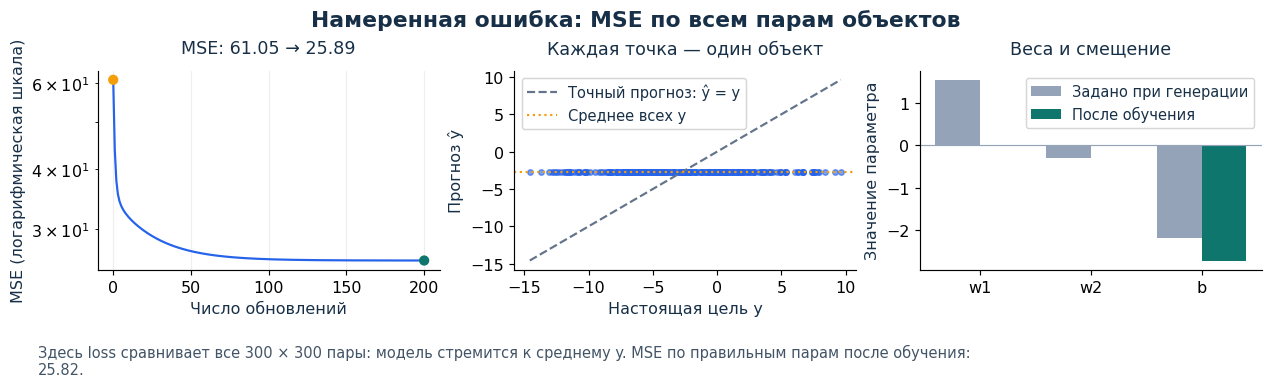

In [172]:
layer(x).shape

torch.Size([300, 1])

In [173]:
x.shape

torch.Size([300, 2])

In [174]:
y.shape

torch.Size([300])

In [176]:
y.unsqueeze(0).shape

torch.Size([1, 300])

In [180]:
(layer(x) - y).shape

torch.Size([300, 300])

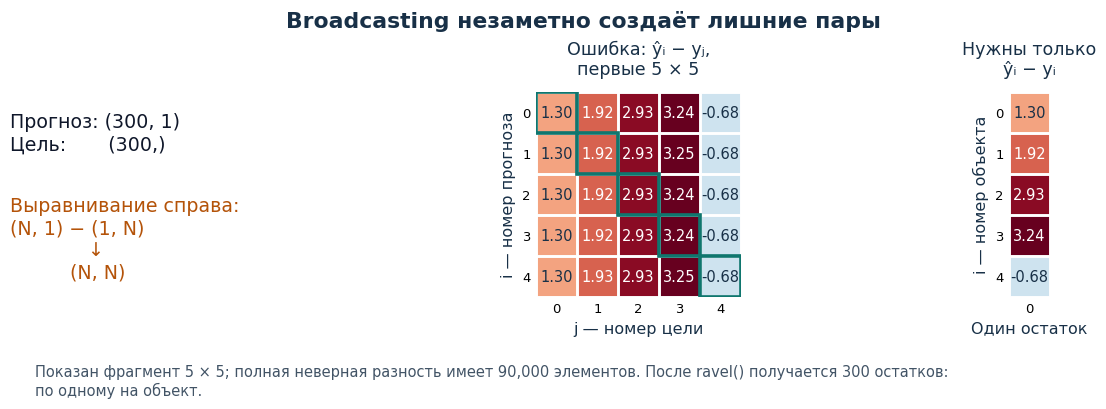

In [177]:
layer(x).ravel().shape

torch.Size([300])

In [178]:
(layer(x).ravel() - y).shape

torch.Size([300])

In [179]:
layer = nn.Linear(in_features=n_features, out_features=1)

for i in range(n_steps):
    y_pred = layer(x).ravel()

    mse = torch.mean((y_pred - y) ** 2)

    if i < 20 or i % 10 == 0:
        print(f'MSE на шаге {i + 1} {mse.item():.5f}')

    mse.backward()

    with torch.no_grad():
        layer.weight -= layer.weight.grad * step_size
        layer.bias -= layer.bias.grad * step_size

    layer.zero_grad()

MSE на шаге 1 82.40031
MSE на шаге 2 34.83059
MSE на шаге 3 18.67639
MSE на шаге 4 12.57786
MSE на шаге 5 9.87140
MSE на шаге 6 8.42349
MSE на шаге 7 7.51441
MSE на шаге 8 6.87739
MSE на шаге 9 6.39865
MSE на шаге 10 6.02125
MSE на шаге 11 5.71254
MSE на шаге 12 5.45201
MSE на шаге 13 5.22616
MSE на шаге 14 5.02584
MSE на шаге 15 4.84476
MSE на шаге 16 4.67857
MSE на шаге 17 4.52421
MSE на шаге 18 4.37955
MSE на шаге 19 4.24304
MSE на шаге 20 4.11358
MSE на шаге 21 3.99035
MSE на шаге 31 3.01138
MSE на шаге 41 2.35799
MSE на шаге 51 1.91931
MSE на шаге 61 1.62472
MSE на шаге 71 1.42689
MSE на шаге 81 1.29405
MSE на шаге 91 1.20484
MSE на шаге 101 1.14493
MSE на шаге 111 1.10470
MSE на шаге 121 1.07768
MSE на шаге 131 1.05954
MSE на шаге 141 1.04736
MSE на шаге 151 1.03917
MSE на шаге 161 1.03368
MSE на шаге 171 1.02999
MSE на шаге 181 1.02751
MSE на шаге 191 1.02585


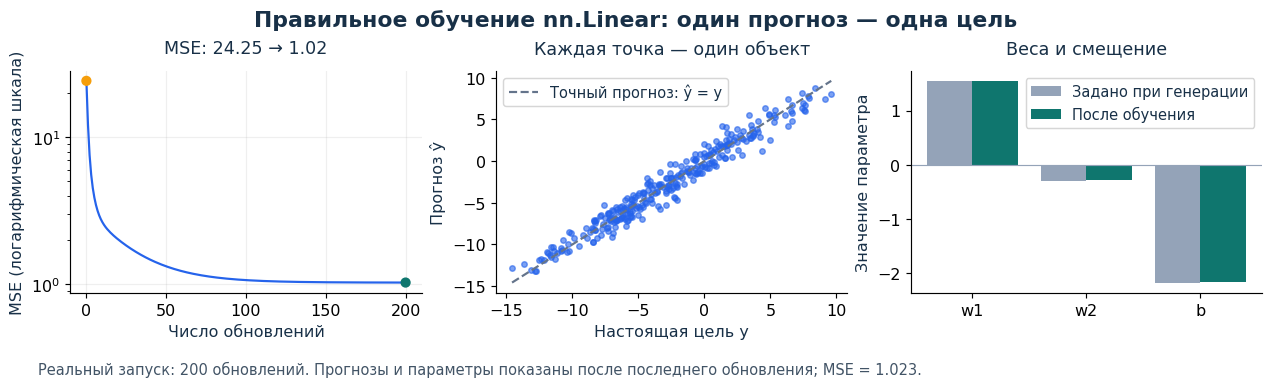

In [180]:
n_features = 5
n_objects = 300

torch.manual_seed(0)

w_true = torch.randn(n_features)

x = (torch.rand(n_objects, n_features) - 0.5) * 10 * (torch.arange(n_features) * 2 + 1)
y = torch.matmul(x, w_true) + torch.randn(n_objects)

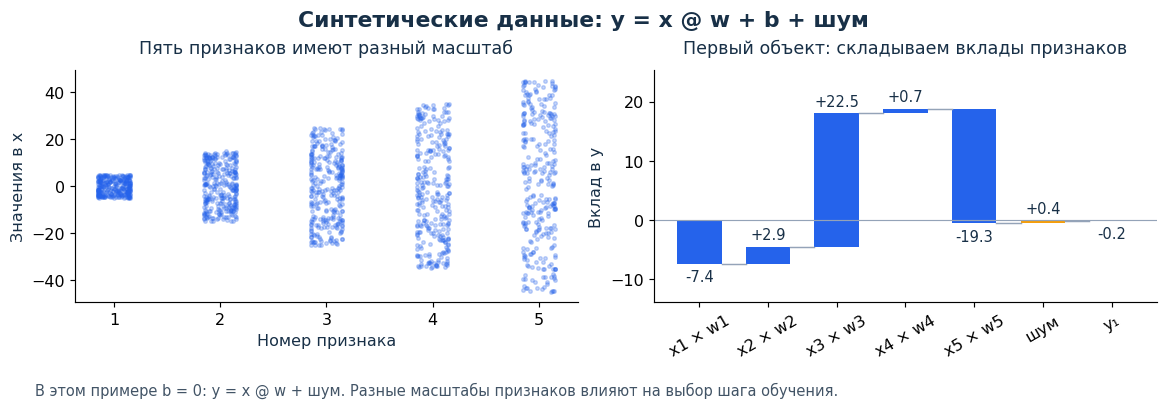

In [181]:
x.shape, y.shape

(torch.Size([300, 5]), torch.Size([300]))

In [182]:
n_steps = 500
step_size = 1e-3

In [183]:
layer = nn.Linear(in_features=n_features, out_features=1)

for i in range(n_steps):
    y_pred = layer(x).ravel()

    mse = torch.mean((y_pred - y) ** 2)

    if i < 20 or i % 50 == 0:
        print(f'MSE на шаге {i + 1} {mse.item():.5f}')

    mse.backward()

    with torch.no_grad():
        layer.weight -= layer.weight.grad * step_size
        layer.bias -= layer.bias.grad * step_size

    layer.zero_grad()

MSE на шаге 1 1522.64282
MSE на шаге 2 345.22870
MSE на шаге 3 134.71320
MSE на шаге 4 69.14159
MSE на шаге 5 45.61798
MSE на шаге 6 36.15923
MSE на шаге 7 31.74179
MSE на шаге 8 29.24492
MSE на шаге 9 27.53952
MSE на шаге 10 26.19924
MSE на шаге 11 25.05364
MSE на шаге 12 24.02866
MSE на шаге 13 23.08827
MSE на шаге 14 22.21260
MSE на шаге 15 21.38941
MSE на шаге 16 20.61047
MSE на шаге 17 19.86992
MSE на шаге 18 19.16344
MSE на шаге 19 18.48770
MSE на шаге 20 17.84015
MSE на шаге 51 6.27402
MSE на шаге 101 1.74083
MSE на шаге 151 1.02593
MSE на шаге 201 0.91269
MSE на шаге 251 0.89435
MSE на шаге 301 0.89104
MSE на шаге 351 0.89019
MSE на шаге 401 0.88977
MSE на шаге 451 0.88948


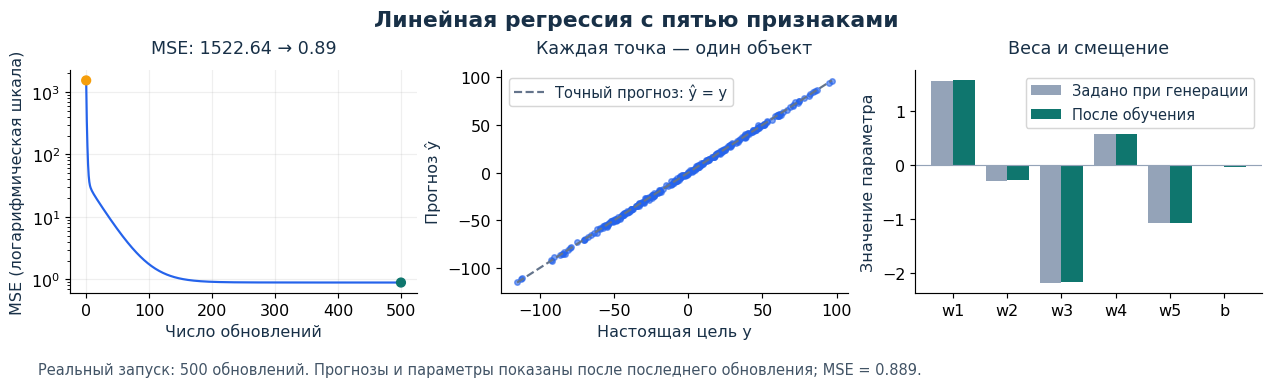

In [184]:
n_steps = 1000
step_size = 3e-4

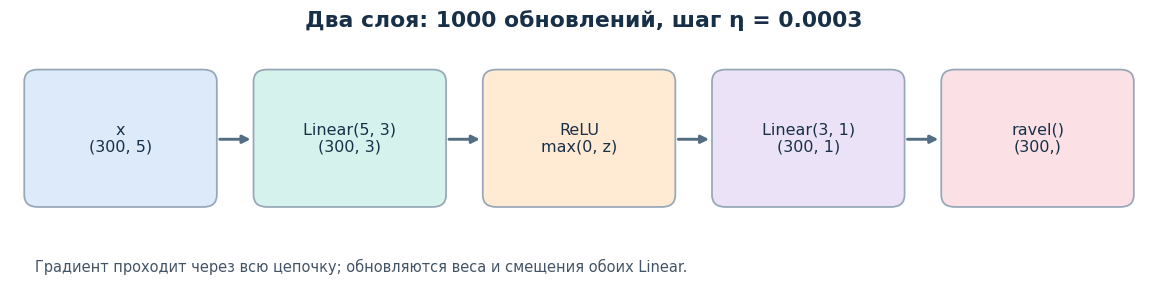

In [185]:
layer1 = nn.Linear(in_features=n_features, out_features=3)
layer2 = nn.Linear(in_features=3, out_features=1)
activation = nn.ReLU()


for i in range(n_steps):
    y_pred = layer2(activation(layer1(x))).ravel()

    mse = torch.mean((y_pred - y) ** 2)

    if i < 20 or i % 50 == 0:
        print(f'MSE на шаге {i + 1} {mse.item():.5f}')

    mse.backward()

    with torch.no_grad():
        layer1.weight -= layer1.weight.grad * step_size
        layer1.bias -= layer1.bias.grad * step_size
        layer2.weight -= layer2.weight.grad * step_size
        layer2.bias -= layer2.bias.grad * step_size

    layer1.zero_grad()
    layer2.zero_grad()

MSE на шаге 1 2065.53369
MSE на шаге 2 1941.40039
MSE на шаге 3 1890.73816
MSE на шаге 4 1863.17334
MSE на шаге 5 1843.74536
MSE на шаге 6 1825.21838
MSE на шаге 7 1803.15234
MSE на шаге 8 1775.96960
MSE на шаге 9 1741.44421
MSE на шаге 10 1696.50024
MSE на шаге 11 1638.66479
MSE на шаге 12 1570.60828
MSE на шаге 13 1498.17651
MSE на шаге 14 1426.69543
MSE на шаге 15 1361.06189
MSE на шаге 16 1304.04346
MSE на шаге 17 1252.44177
MSE на шаге 18 1201.12524
MSE на шаге 19 1142.44934
MSE на шаге 20 1069.69458
MSE на шаге 51 10.77816
MSE на шаге 101 5.31390
MSE на шаге 151 3.22006
MSE на шаге 201 2.08226
MSE на шаге 251 1.45981
MSE на шаге 301 1.16964
MSE на шаге 351 1.03444
MSE на шаге 401 0.97123
MSE на шаге 451 0.94165
MSE на шаге 501 0.92668
MSE на шаге 551 0.91742
MSE на шаге 601 0.91137
MSE на шаге 651 0.90724
MSE на шаге 701 0.90359
MSE на шаге 751 0.90093
MSE на шаге 801 0.89879
MSE на шаге 851 0.89742
MSE на шаге 901 0.89643
MSE на шаге 951 0.89556


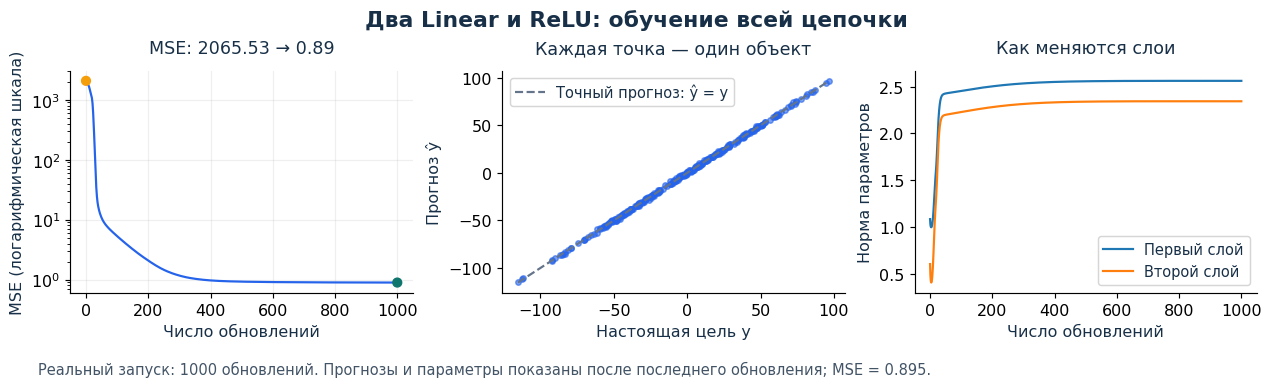

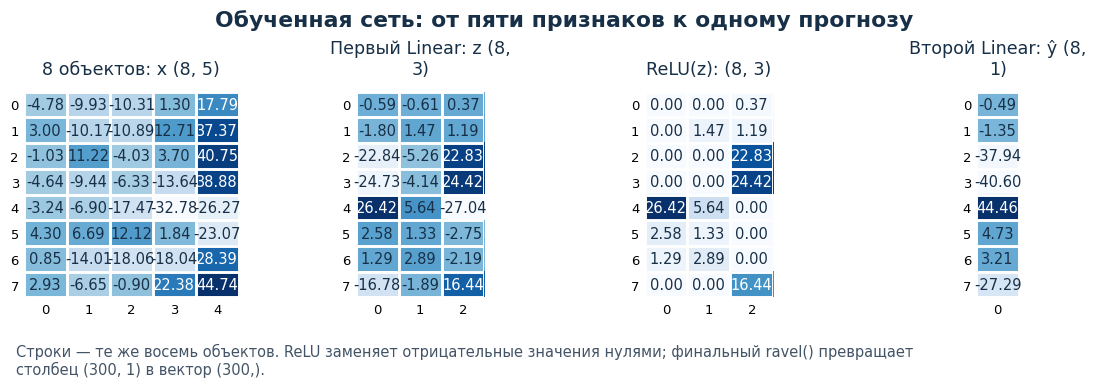